In [54]:
from sklearn import preprocessing
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score, mean_absolute_percentage_error


# For 2D analysis
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from scipy.optimize import curve_fit
# from utils import period2freq, freq2period

# For PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import csv
import time
import glob

# Datasize in KB
data_size_kb = {'4mb': 4096, '16mb': 16384, '64mb': 65536,
            '256mb': 262144, '512mb': 524288, '1gb': 1048576,
            '5gb': 5242880, '50gb': 52428800, '100gb': 104857600,
            '300gb': 314572800,}

# Key Parameters
IOR_PARAMS = ['operation', 'randomOffset', 'transferSize', 
            'aggregateFilesizeMB', 'numTasks', 'totalTime', 
            'numNodes', 'tasksPerNode', 'bwMiB', "storageType"]

TARGET_PARAMS = [ "bestStorage" ]
op_dict = {0: "write", 1: "read"}


## Bandwidth Prediction from IOR to Workflow
### Key parameters from IOR
Parameters for emulation:
- D: Total I/O size per task per operation (take log scale)
- C: Total I/O operation count per operation type, [Cr, Cw]
- A: Average I/O size per operation type, [Ar, Aw]
- IOT: I/O opeartion type per task (seq/ran, read/write), [OTsr, OTsw, OTrr, OTrw]
- N: Number of parallelism/tasks 
- OSC: Size of OS buffered cache
- Mem: Size of memory
Parameters for prediciton:
- TIO: Total I/O size for all tasks
- T: Time spend on the type of I/O operation per task, [Tr, Tw]
- BW: Bandwidth calculated from TIO/T
### Special note for IOR
IOR calculates bwMiB, but the bwMiB is little slower than the (aggregate filesize)/totalTime, but not much difference, particularly in the `totalTime=openTimewrRdTime+closetime`

### Key parameters from workflow
Parameters for characteristics
- D: Total I/O size per task per operation (take log scale)
- C: Total I/O operation count per operation type, [Cr, Cw]
- A: Average I/O size per operation type, calculate from A=D/C [Ar, Aw]
- IOT: I/O opeartion type per task (seq/ran, read/write), [OTsr, OTsw, OTrr, OTrw]
- N: Number of parallelism/tasks 
- OSC: Size of OS buffered cache
- Mem: Size of memory
Parameters for prediciton:
- TIO: Total I/O size for all tasks
- T: Time spend on the type of I/O operation per task, [Tr, Tw]
- BW: Bandwidth calculated from TIO/T

### Perf Modeling Parameters
- a: Performance change when total data size reaches memory buffer cache of system.
- b: Performance change when  total data size reaches memory size of system. (Constant value)
- v: Performance variation due to shared storage resource. 
(The peak variation in the system. Measure with IOR.)
Deception BeeGFS: run at off hour to keep below 20% variation.
Options: (1) User/system admin to ensure the variation percentage; 
(2) Obtain variation with IOR emulation (possible over 20%)
- r: Range of expected performance: Make correct choice with given storage options.
- LPMR: Layered performance matching number for comparing application storage choice.
- w: Weight of a application LPMR. (Total data size, cost of moving data)



# TODO
- normalize BW differently! use same log scale for all (DONE)
- BeeGFS graph show variance:
    - identify whether the performance changes is due to BeeGFS parameters or due to traffic
    - parameter: distribution, tell us the load at particular time, background traffic under a percentage 5%, parameter it self can be a range.
    - Microbenchmark on background load, in principle that we know this exists and we assume we know a load factor, adjust the results. Whether it affect the storage choice for a type of workload.
    

In [55]:
def byte_size_to_human_size(byte_size):
    if byte_size < 1024:
        return f"{byte_size} B"
    elif byte_size < 1024**2:
        return f"{byte_size/1024} KiB"
    elif byte_size < 1024**3:
        return f"{byte_size/1024**2} MiB"
    elif byte_size < 1024**4:
        return f"{byte_size/1024**3} GiB"
    else:
        return f"{byte_size/1024**4} TiB"

def file_size_to_mb(file_size):
    # If file_size is type string, convert to float
    if type(file_size) == str:
        # Translate KiB, MiB, and GiB to bytes
        size_num = float(file_size.split(" ")[0])
        size_unit = file_size.split(" ")[1]
        if size_unit == "KiB":
            return float(size_num/1024)
        elif size_unit == "MiB":
            return float(size_num)
        elif size_unit == "GiB":
            return float(size_num * 1024)
        else:
            # If file_size is type int, convert to MB
            return int(size_num/1024**2)
    else:
        # If file_size is type int, convert to MB
        return int(file_size/1024**2)

def transform_store_code(storage_type):
    if storage_type == "localssd":
        store_code = 0
    elif storage_type == "beegfs":
        store_code = 1
    elif storage_type == "lustre":
        store_code = 2
    else:
        store_code = 3
    return store_code

def decode_store_code(store_code):
    if store_code == 0:
        storage_type = "localssd"
    elif store_code == 1:
        storage_type = "beegfs"
    elif store_code == 2:
        storage_type = "lustre"
    else:
        storage_type = "unknown"
    return storage_type

def get_ior_json_df(ior_test_json_files, storage_type, IOR_PARAMS):


    # Create a dataframe for storing ior parameters
    ior_df = pd.DataFrame(columns=IOR_PARAMS)
    store_code = transform_store_code(storage_type)

    # Load Json files
    for jfile in ior_test_json_files:
        with open(jfile) as f:
            try:
                data = json.load(f)
            except:
                print("Error reading file: ", jfile)
                continue
            # print(jfile)
            
            # Write then Read
            ior_options = data['tests'][0]["Options"]
            IOR_PARAMS = data['tests'][0]["Parameters"]

            # Add write statistics first
            if file_size_to_mb(ior_options['aggregate filesize']) != 0:
                tmp_write_stat = {}
                ior_write_summary = data['summary'][0]
                tmp_write_stat['randomOffset'] = IOR_PARAMS['randomOffset']
                tmp_write_stat['aggregateFilesizeMB'] = file_size_to_mb(ior_options['aggregate filesize'])
                tmp_write_stat['numTasks'] = ior_write_summary['numTasks']
                tmp_write_stat['tasksPerNode'] = ior_write_summary['tasksPerNode']
                tmp_write_stat['numNodes'] = tmp_write_stat['numTasks']/tmp_write_stat['tasksPerNode']
                tmp_write_stat['transferSize'] = ior_write_summary['transferSize']
                if ior_write_summary['operation'] == "write":
                    tmp_write_stat['operation'] = 0
                else:
                    tmp_write_stat['operation'] = -1
                tmp_write_stat['totalTime'] = ior_write_summary['MeanTime'] # only 1 operation per test
                tmp_write_stat['bwMiB'] = ior_write_summary['bwMeanMIB'] # only 1 operation per test
                tmp_write_stat['storageType'] = store_code
                # Add tmp_write_stat to df
                ior_df = ior_df._append(tmp_write_stat, ignore_index=True)

                # Add read statistics
                tmp_read_stat = {}
                ior_read_summary = data['summary'][1]
                tmp_read_stat['randomOffset'] = IOR_PARAMS['randomOffset']
                tmp_read_stat['aggregateFilesizeMB'] = file_size_to_mb(ior_options['aggregate filesize'])
                tmp_read_stat['numTasks'] = ior_read_summary['numTasks']
                tmp_read_stat['tasksPerNode'] = ior_read_summary['tasksPerNode']
                tmp_read_stat['numNodes'] = tmp_read_stat['numTasks']/tmp_read_stat['tasksPerNode']
                tmp_read_stat['transferSize'] = ior_read_summary['transferSize']
                if ior_read_summary['operation'] == "read":
                    tmp_read_stat['operation'] = 1
                else:
                    tmp_read_stat['operation'] = -1
                tmp_read_stat['totalTime'] = ior_read_summary['MeanTime']
                tmp_read_stat['bwMiB'] = ior_read_summary['bwMeanMIB']
                tmp_read_stat['storageType'] = store_code
                # Add tmp_read_stat to df
                ior_df = ior_df._append(tmp_read_stat, ignore_index=True)

    # encode string to numbers
    le = preprocessing.LabelEncoder()
    for col in ior_df.columns:
        if pd.api.types.is_string_dtype(ior_df[col]):
            ior_df[col] = le.fit_transform(ior_df[col])

    # print(ior_df.head(5))

    return ior_df

def plot_heatmap(corrM,outfile):
    plt.figure(figsize=(14, 8))
    #labels = list(corrM.columns)
    plt.subplots_adjust(bottom=0.19)

    # # use only lower triangle
    # corrM = corrM.where(np.triu(np.ones(corrM.shape)).astype(np.bool))

    ## plot all correlation heatmap
    map = sns.heatmap(corrM, vmin=-1, vmax=1,
        linewidths=0.5, linecolor='grey', cmap='BrBG') #annot=True,
    map.set_title('Correlation Matrix Heatmap', fontdict={'fontsize':12}, pad=12)
    #plt.show()
    out_file=f'{outfile}.png'
    plt.savefig(out_file)
    plt.clf()

def get_redundant_pairs(df):
    '''Get diagonal and lower triangular pairs of correlation matrix'''
    pairs_to_drop = set()
    cols = df.columns
    for i in range(0, df.shape[1]):
        for j in range(0, i+1):
            pairs_to_drop.add((cols[i], cols[j]))
    return pairs_to_drop
    
def corrM_sorted_csv(corrM, outfile):
  n=5
  au_corr = corrM.corr().abs().unstack()
  labels_to_drop = get_redundant_pairs(corrM)
  au_corr = au_corr.drop(labels=labels_to_drop).sort_values(ascending=False)
  sorted_corrM = au_corr[0:n]

  out_file= outfile
  sorted_corrM.to_csv(out_file)

def corr_matrix(df,outname=""):

    # calculte correlation matrix
    corrM = df.corr()

    corrM.to_csv(f'{outname}.csv')
    plot_heatmap(corrM,outname)
    #corrM_sorted_csv(corrM, f'sorted_{outname}.csv')

def _2d_trend(X, y, x_label="x-axis", y_label="bwMiB", title="", show=False):
        # X = X.reshape(-1, 1)
        X = X.values.reshape(-1, 1)
        # poly = PolynomialFeatures(degree=2)
        poly = PolynomialFeatures(degree=1)
        poly_data = poly.fit_transform(X)
        model = LinearRegression()
        model.fit(poly_data,y)
        coef = model.coef_
        intercept = model.intercept_
        # Set figure size (80,50)
        plt.figure(figsize=(10,5))

        plt.scatter(X,y,color='red')
        plt.plot(X,model.predict(poly.fit_transform(X)),color='blue')
        # Show the fit parameters on graph with scientific notation
        plt.annotate(f"y = {coef[1]:.2e}x + {intercept:.2e}", xy=(0.05, 0.95), xycoords='axes fraction')

        # print(f"y = {coef[1]}x + {intercept}")
        plt.legend(['Original','Prediction'])
        plt.xlabel(x_label)
        plt.ylabel(y_label)
        plt.title(title)
        if show:
            plt.show()
        return coef[1], intercept

def _3d_trend(x,y,z, title=""):
    # ref: https://stackoverflow.com/questions/2298390/fitting-a-line-in-3d
    # Convert Pandas Series to NumPy arrays
    x = x.to_numpy()
    y = y.to_numpy()
    z = z.to_numpy()
    
    data = np.concatenate((x[:, np.newaxis], 
                        y[:, np.newaxis], 
                        z[:, np.newaxis]), 
                        axis=1)
    
    data = data.astype('float64')

    # Calculate the mean of the points, i.e. the 'center' of the cloud
    datamean = data.mean(axis=0)
    print(datamean)

    # Do an SVD on the mean-centered data.
    # full_matrices=False reduce memory
    uu, dd, vv = np.linalg.svd(data - datamean, full_matrices=False)

    # Get the sptread of data with mean 0 from all axis
    x_min = np.min(data[:,0])
    y_min = np.min(data[:,1])
    z_min = np.min(data[:,2])

    x_max = np.max(data[:,0])
    y_max = np.max(data[:,1])
    z_max = np.max(data[:,2])

    low_bound = min(x_min, y_min, z_min)
    high_bound = max(x_max, y_max, z_max)

    # Now vv[0] contains the first principal component, i.e. the direction
    # vector of the 'best fit' line in the least squares sense.
    # Adjust axist limits (Optional)
    linepts = vv[0] * np.mgrid[low_bound:high_bound:2j][:, np.newaxis]
    # shift by the mean to get the line in the right place
    linepts += datamean

    # Verify that everything looks right.

    # import mpl_toolkits.mplot3d as m3d
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter3D(*data.T)
    ax.plot3D(*linepts.T)
    # ax.scatter3D(data[:,0], data[:,1], data[:,2])
    ax.set_xlabel("transferSize")
    ax.set_ylabel("aggregateFilesizeMB")
    ax.set_zlabel("bwMiB")
    ax.set_title(title)
    plt.show()



In [56]:

def _polynomial_fit_pca(df, title):
    # Standardizing the data
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df)

    # Performing PCA
    pca = PCA(n_components=2)  # Reduce to 2 components for visualization
    principal_components = pca.fit_transform(scaled_data)

    # Creating a DataFrame with the principal components
    pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

    # Define a polynomial function to fit
    def polynomial_func(x, a, b, c):
        return a * x**2 + b * x + c

    # Fit the polynomial curve
    params, _ = curve_fit(polynomial_func, pca_df['PC1'], pca_df['PC2'])

    # Predict values using the fitted curve
    x_vals = np.linspace(pca_df['PC1'].min(), pca_df['PC1'].max(), 100)
    fitted_curve = polynomial_func(x_vals, *params)

    # Visualizing the PCA result and the fitted curve
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='PC1', y='PC2', data=pca_df, label='PCA Data')
    plt.plot(x_vals, fitted_curve, color='red', label='Polynomial Fit')
    plt.title(title)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend()
    plt.show()

    # Curve fit parameters
    print(f'Polynomial fit parameters: a={params[0]}, b={params[1]}, c={params[2]}')

    # Reconstructing the data from the principal components
    reconstructed_data = pca.inverse_transform(principal_components)

    # Calculating the reconstruction error
    mse = mean_squared_error(scaled_data, reconstructed_data)
    print(f'Reconstruction error (MSE): {mse}')

    # Explained variance
    explained_variance = pca.explained_variance_ratio_
    print(f'Explained variance by principal components: {explained_variance}')


def _linear_fit_pca(df, title):
    # Standardizing the data
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df)

    # Performing PCA
    pca = PCA(n_components=2)  # Reduce to 2 components for visualization
    principal_components = pca.fit_transform(scaled_data)

    # Creating a DataFrame with the principal components
    pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

    # Fit the linear regression model
    reg = LinearRegression()
    reg.fit(pca_df[['PC1']], pca_df['PC2'])

    # Predict values using the fitted model
    x_vals = np.linspace(pca_df['PC1'].min(), pca_df['PC1'].max(), 100)
    fitted_line = reg.predict(x_vals.reshape(-1, 1))

    # Visualizing the PCA result and the fitted line
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='PC1', y='PC2', data=pca_df, label='PCA Data')
    plt.plot(x_vals, fitted_line, color='red', label='Linear Fit')
    plt.title(title)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend()
    plt.show()

    # Linear fit parameters
    print(f'Linear fit parameters: intercept={reg.intercept_}, slope={reg.coef_[0]}')

    # Reconstructing the data from the principal components
    reconstructed_data = pca.inverse_transform(principal_components)

    # Calculating the reconstruction error
    mse = mean_squared_error(scaled_data, reconstructed_data)
    print(f'Reconstruction error (MSE): {mse}')

    # Explained variance
    explained_variance = pca.explained_variance_ratio_
    print(f'Explained variance by principal components: {explained_variance}')


def ior_json_to_df(ior_data_path):
    # Get the list of JSON files from the directory
    ior_test_json_files = glob.glob(ior_data_path + "/*.json")

    # Get storage type from data_path name
    # storage_type =  ior_data_path.split("/")[-1].split("_")[0] + "_" + ior_data_path.split("/")[-1].split("_")[1]
    storage_type =  ior_data_path.split("/")[-1].split("_")[0]
    # print("Storage Type: ", storage_type)
    ior_df = get_ior_json_df(ior_test_json_files, storage_type, IOR_PARAMS)

    # corr_matrix(ior_df, storage_type)

    return ior_df

# Take a column name for y_data
def x_mean_std(group, y_column):
    return pd.Series({
        f'{y_column}_ave': group[y_column].mean(),
        f'{y_column}_ave_std': group[y_column].std(ddof=0)  # Use population standard deviation by setting ddof=0
    })

from sklearn.preprocessing import MinMaxScaler
def my_data_transform(df, cols_to_norm=[], cols_to_log=[]):
    # Create an empty DataFrame to store the results
    results = []

    # Get unique transfer sizes and number of tasks
    xfersizes = sorted(df['transferSize'].unique())
    numTasks = sorted(df['numTasks'].unique())
    op_type = [0, 1]  # Define outside the loop to avoid redefinition
    print("Transfer Sizes: ", xfersizes)
    print("Number of Tasks: ", numTasks)

    for xfer in xfersizes:
        for t in numTasks:
            for op in op_type:
                # Filter the DataFrame for specific conditions
                subdf = df[(df['numTasks'] == t) &
                           (df['transferSize'] == xfer) &
                           (df['operation'] == op)].copy()
                
                if not subdf.empty:
                    # Calculate the mean and standard deviation of the bwMiB column
                    ave_bw_df = subdf.groupby('aggregateFilesizeMB').apply(
                        lambda group: x_mean_std(group, 'bwMiB')
                    ).reset_index()

                    # Calculate percentage of standard deviation
                    ave_bw_df['bwMiB_ave_std_perc'] = (ave_bw_df['bwMiB_ave_std'] /
                                                       ave_bw_df['bwMiB_ave']) * 100

                    # Merge the aggregated results with the original DataFrame
                    merged_df = pd.merge(subdf, ave_bw_df, on='aggregateFilesizeMB', how='left')

                    # Append the merged DataFrame to the results list
                    results.append(merged_df)

    # Concatenate all the DataFrames in the results list
    new_df = pd.concat(results, ignore_index=True)

    # Log transformation
    if cols_to_log:
        log_new_cols = [f"{col}_log" for col in cols_to_log]
        print("Columns to log: ", cols_to_log)
        new_df[log_new_cols] = np.log(new_df[cols_to_log])

    # Min-Max normalization
    if cols_to_norm:
        norm_new_cols = [f"{col}_norm" for col in cols_to_norm]
        print("Columns to normalize: ", cols_to_norm)
        scaler = MinMaxScaler()
        new_df[norm_new_cols] = scaler.fit_transform(new_df[cols_to_norm])

    return new_df

def oscillatory_func(x, amplitude, frequency, phase, offset):
    return amplitude * np.sin(frequency * x + phase) + offset

def damped_sine_func(x, amplitude, frequency, phase, offset, decay):
    return amplitude * np.sin(frequency * x + phase) * np.exp(-decay * x) + offset

def cos_func(x, amplitude, frequency):
    return amplitude * np.cos(frequency * x)

def normalize_y(y_data):
    scaler = MinMaxScaler(feature_range=(-1, 1))
    return scaler.fit_transform(y_data.values.reshape(-1, 1)).flatten()

def _oscillatory_trend(x_data, y_data, x_label="x-axis", y_label="bwMiB", title="", 
                       show=False, x_datalabel=[], y_datalabel=[], save_path=""):
    # Normalize y_data
    y_data_normalized = y_data #normalize_y(y_data)
    
    # Initial guess for the parameters
    amplitude_guess = (np.max(y_data_normalized) - np.min(y_data_normalized)) / 2
    frequency_guess = 10
    if y_data_normalized[1] > y_data_normalized[0]:
        phase_guess = 0
    else:
        phase_guess = np.pi
    offset_guess = np.mean(y_data_normalized)
    initial_guess = [amplitude_guess, frequency_guess, phase_guess, offset_guess]

    try:
        # Fit the oscillatory function to the normalized data
        params, params_covariance = curve_fit(oscillatory_func, x_data, y_data_normalized, p0=initial_guess, maxfev=10000)
        # params, params_covariance = curve_fit(cos_func, x_data, y_data_normalized, p0=(amplitude_guess, frequency_guess), maxfev=10000)
    except RuntimeError as e:
        print(f"Sine wave fitting failed: {e}")
        # Attempt to fit a damped sine wave if the initial fit fails
        decay_guess = 0.1
        frequency_guess = 20
        # phase_guess2 = 1
        phase_guess = np.pi
        updated_guess = [amplitude_guess, frequency_guess, phase_guess, offset_guess]
        try:
            params, params_covariance = curve_fit(oscillatory_func, x_data, y_data_normalized, p0=initial_guess, maxfev=10000)
        except RuntimeError as e:
            print(f"Sine wave re-fitting failed: {e}")
            return

    # Print the fitted parameters
    print("Fitted parameters:", params)

    # Generate y values based on the fitted parameters
    if len(params) == 4:
        y_fitted = oscillatory_func(x_data, *params)
        equation = f"y = {params[0]:.2f} * sin({params[1]:.2e}x + {params[2]:.2e}) + {params[3]:.2e}"
    else:
        y_fitted = damped_sine_func(x_data, *params)
        equation = f"y = {params[0]:.2f} * sin({params[1]:.2e}x + {params[2]:.2e}) * exp(-{params[4]:.2e}x) + {params[3]:.2e}"

    # set figure size
    plt.figure(figsize=(10,5))

    # Plot the original data as a scatter plot
    plt.scatter(x_data, y_data_normalized, label='Data')

    # Plot the fitted oscillatory curve
    plt.plot(x_data, y_fitted, color='red', label='Fitted Curve')

    # Add data labels foreach point
    x_label_list = []
    y_label_list = []
    if len(x_datalabel) == len(x_data):
        for i, label in enumerate(x_datalabel):
            x_label_list.append(label)
    if len(y_datalabel) == len(y_data):
        for i, label in enumerate(y_datalabel):
            y_label_list.append(label)
    for i in range(len(x_data)):
        plt.text(x_data[i], y_data_normalized[i], f"{x_label_list[i]}, {y_label_list[i]}", fontsize=8, ha='left', va='bottom')
    
    # Always plot x and y from 0 to 1
    plt.xlim(0, 1)
    # plt.ylim(0, 1)

    # Add labels and legend
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    if title:
        plt.title(title)
    else:
        plt.title('Scatter Plot with Curve Fit')
    plt.legend()
    
    # Write the equation of the fitted curve on the plot
    plt.annotate(equation, xy=(0.05, 0.25), xycoords='axes fraction')
    # Add phase_guess and frequency_guess to the plot
    plt.annotate(f"Phase: {params[2]:.2e}, Frequency: {params[1]:.2e}", xy=(0.05, 0.20), xycoords='axes fraction')

    if show:
        # Show the plot
        plt.show()
    
    if save_path != "":
        # save with plt title
        plt.savefig(f'{save_path}/{title}.png')



Transfer Sizes:  [64.0, 1024.0, 4096.0, 1048576.0, 4194304.0, 16777216.0, 67108864.0, 268435456.0, 1073741824.0]
Number of Tasks:  [1.0, 4.0, 8.0, 16.0, 32.0, 64.0, 128.0]
Columns to log:  ['aggregateFilesizeMB', 'transferSize']
Columns to normalize:  ['aggregateFilesizeMB_log', 'bwMiB']
Transfer Sizes:  [64.0, 1024.0, 4096.0, 1048576.0, 4194304.0, 16777216.0, 67108864.0, 268435456.0, 1073741824.0]
Number of Tasks:  [1.0, 4.0, 8.0, 16.0, 32.0, 64.0, 128.0]
Columns to log:  ['aggregateFilesizeMB', 'transferSize']
Columns to normalize:  ['aggregateFilesizeMB_log', 'bwMiB']
   operation  randomOffset  transferSize  aggregateFilesizeMB  numTasks  \
0        0.0           0.0          64.0               5120.0       1.0   
1        0.0           0.0          64.0               1024.0       1.0   
2        0.0           0.0          64.0               5120.0       1.0   
3        0.0           0.0          64.0               1024.0       1.0   
4        0.0           0.0          64.0       

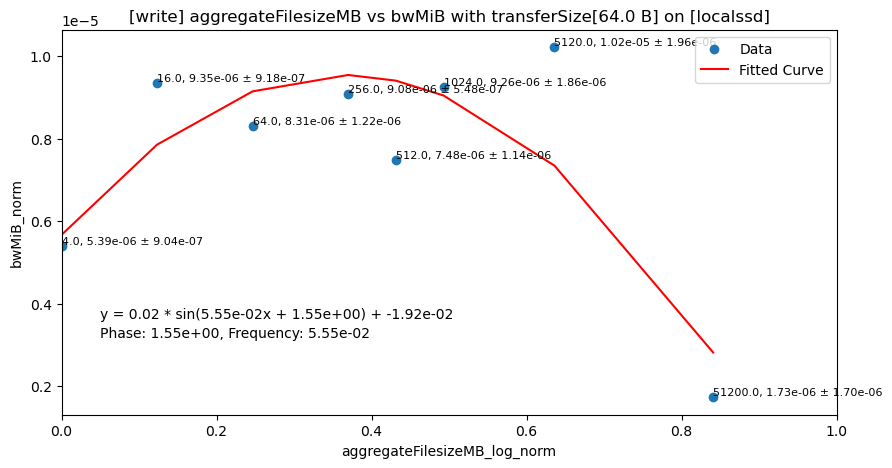

Fitted parameters: [-4.82709459e-06  1.39223927e+01 -2.83722808e+00  3.88699427e-04]


<Figure size 640x480 with 0 Axes>

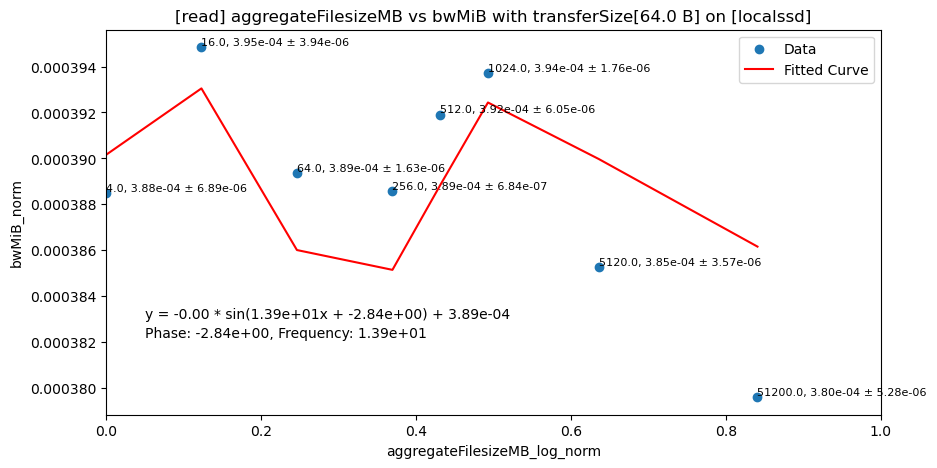

Fitted parameters: [ 1.20860851e-04  1.07414298e+01 -1.89816746e+00  1.74388678e-03]


<Figure size 640x480 with 0 Axes>

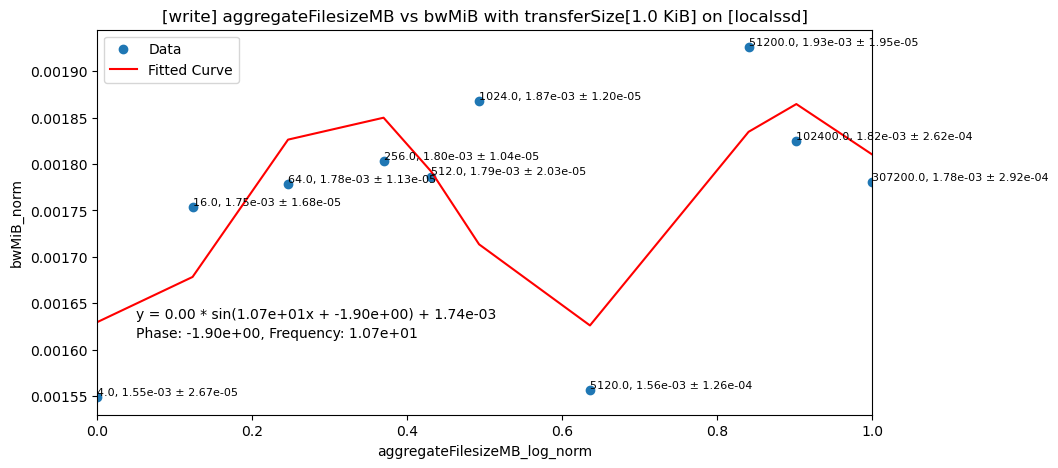

Fitted parameters: [6.28649908e-04 1.49159187e+01 2.32346211e+00 8.59398341e-03]


<Figure size 640x480 with 0 Axes>

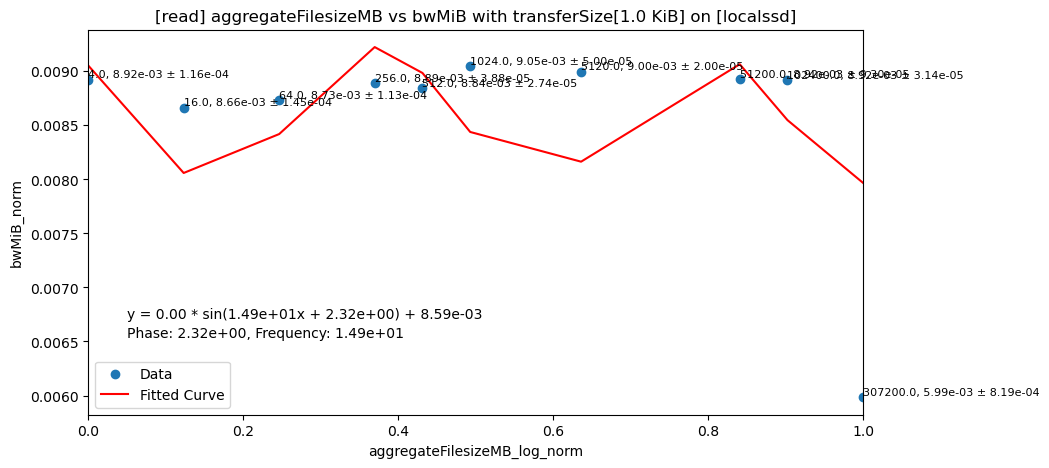

Fitted parameters: [-5.53071621e-04  5.59747599e+00  2.81480715e+00  2.73781384e-03]


<Figure size 640x480 with 0 Axes>

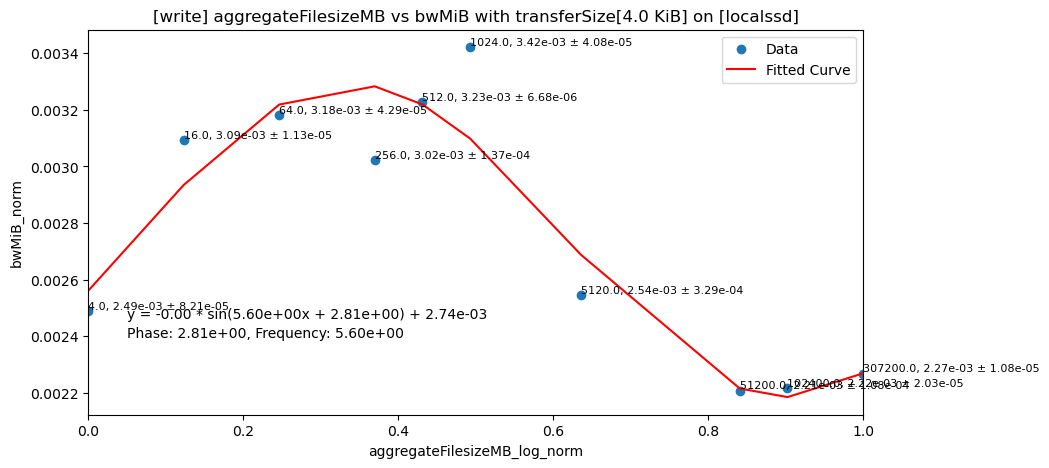

Fitted parameters: [4.75855722e-03 9.24802408e+00 1.88600756e+00 2.15675631e-02]


<Figure size 640x480 with 0 Axes>

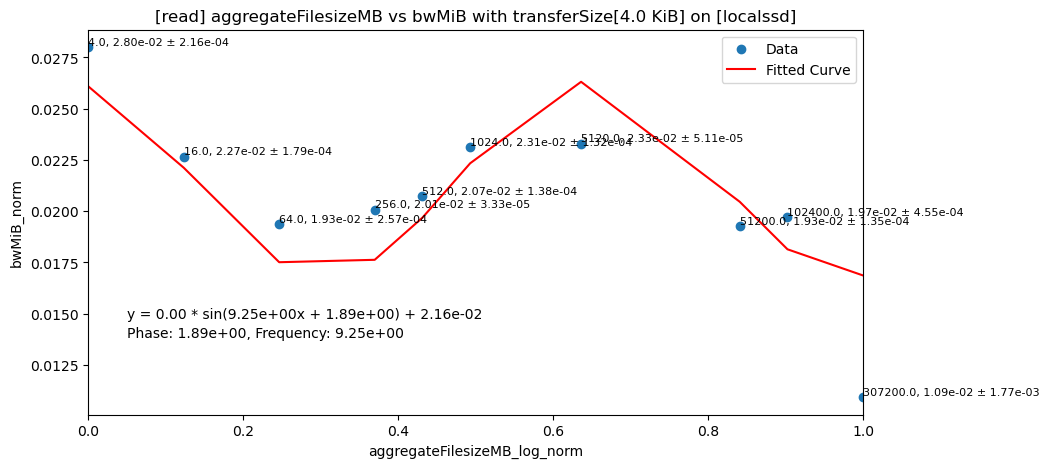

Fitted parameters: [-9.23195658e-04  5.35551224e+00  2.99410048e+00  3.14679700e-03]


<Figure size 640x480 with 0 Axes>

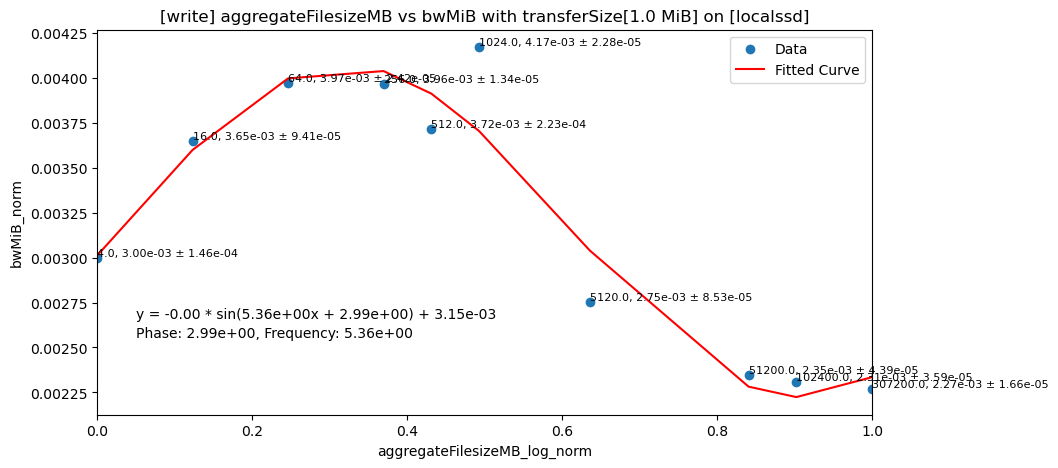

Fitted parameters: [0.00933543 8.6452697  2.43506969 0.0344746 ]


<Figure size 640x480 with 0 Axes>

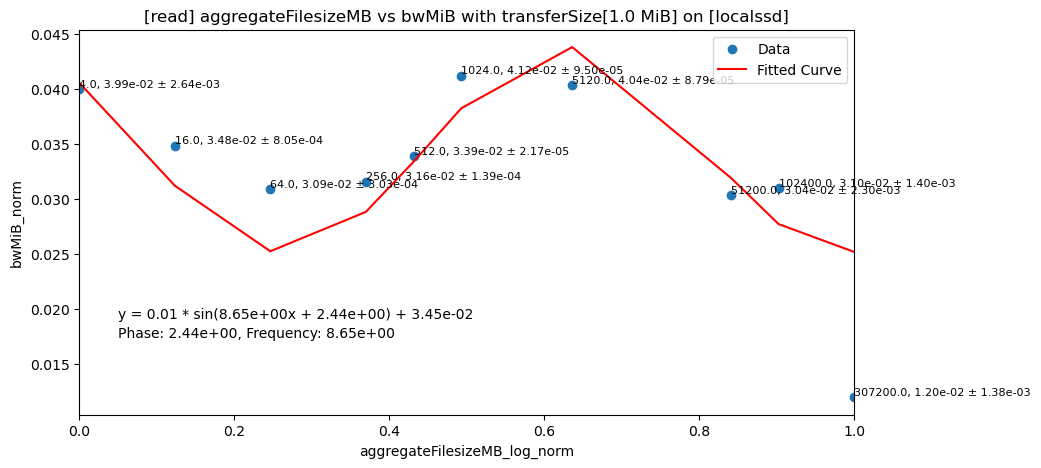

Fitted parameters: [ 4.73793707  0.07909497 10.92870521  4.73959309]


<Figure size 640x480 with 0 Axes>

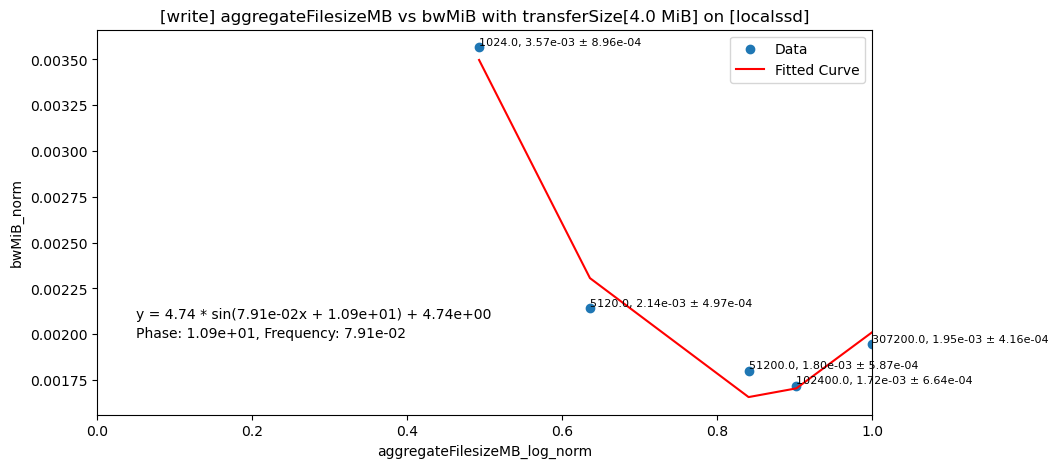

Fitted parameters: [ 59.83237972   0.06948683   7.81389195 -59.78978698]


<Figure size 640x480 with 0 Axes>

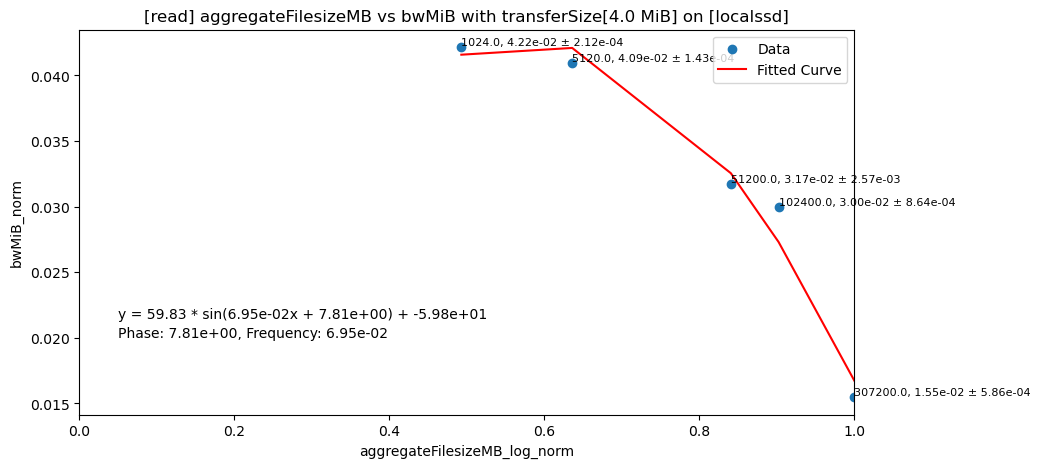

Fitted parameters: [ 4.28609381  0.09216284 10.92103674  4.28800824]


<Figure size 640x480 with 0 Axes>

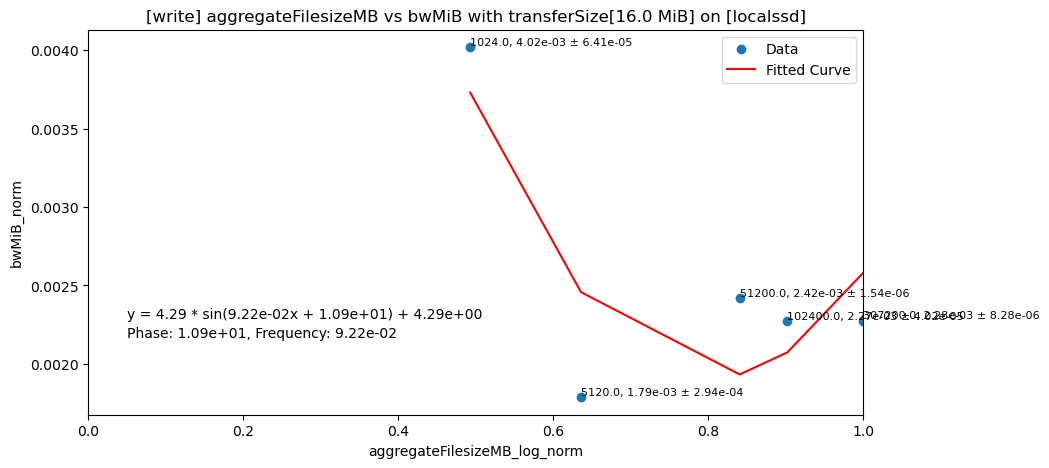

Fitted parameters: [ 59.81753492   0.07203482   7.80929852 -59.7794111 ]


<Figure size 640x480 with 0 Axes>

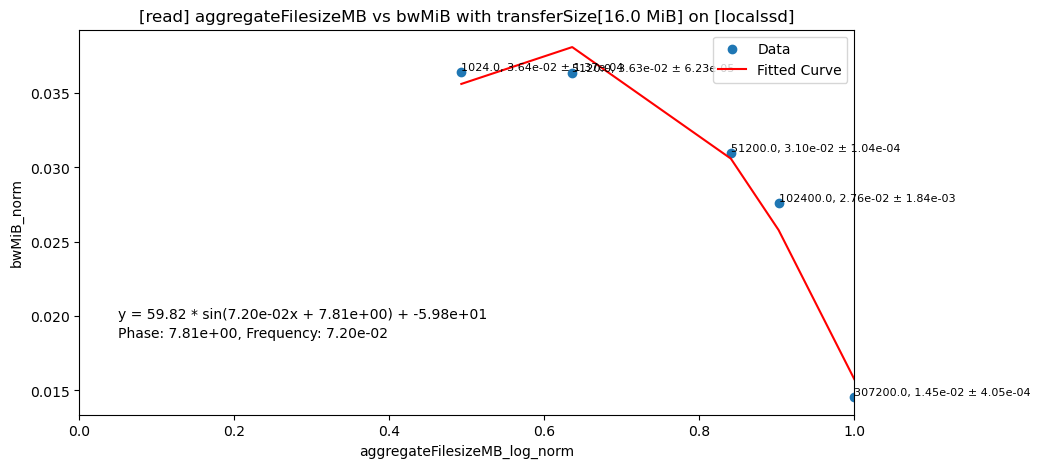

Fitted parameters: [ 4.45133216  0.07714125 10.92944604  4.45351093]


<Figure size 640x480 with 0 Axes>

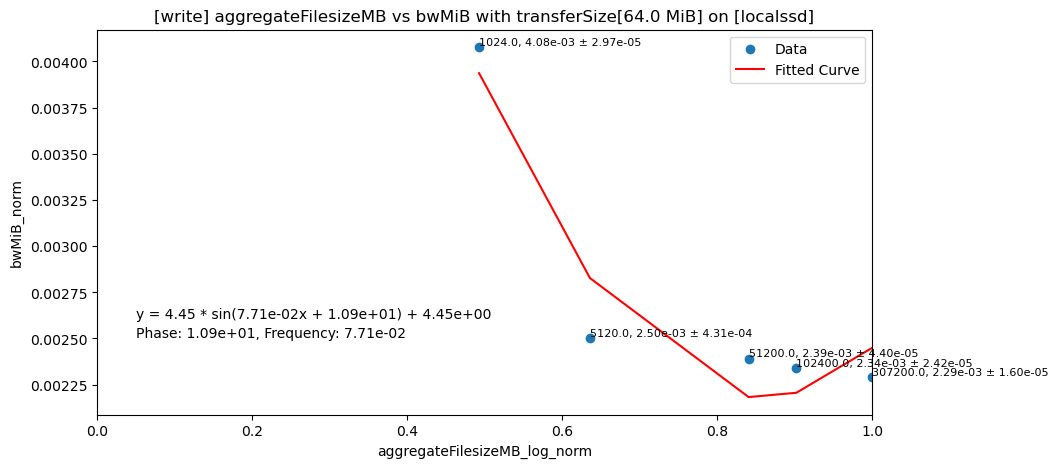

Fitted parameters: [2.65015772e-02 2.91389519e+00 6.13630165e+00 1.91541275e-03]


<Figure size 640x480 with 0 Axes>

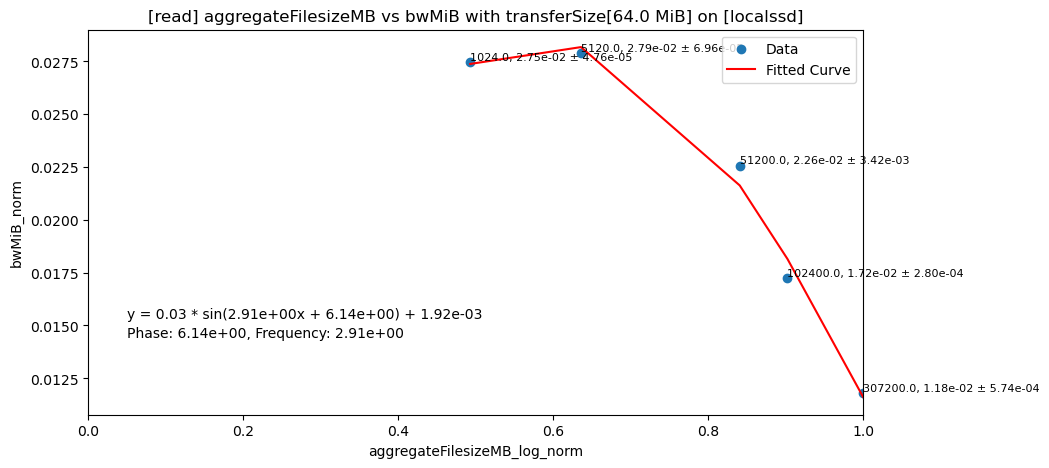

Fitted parameters: [ 1.17630697  0.07226094 10.92728237  1.17864329]


<Figure size 640x480 with 0 Axes>

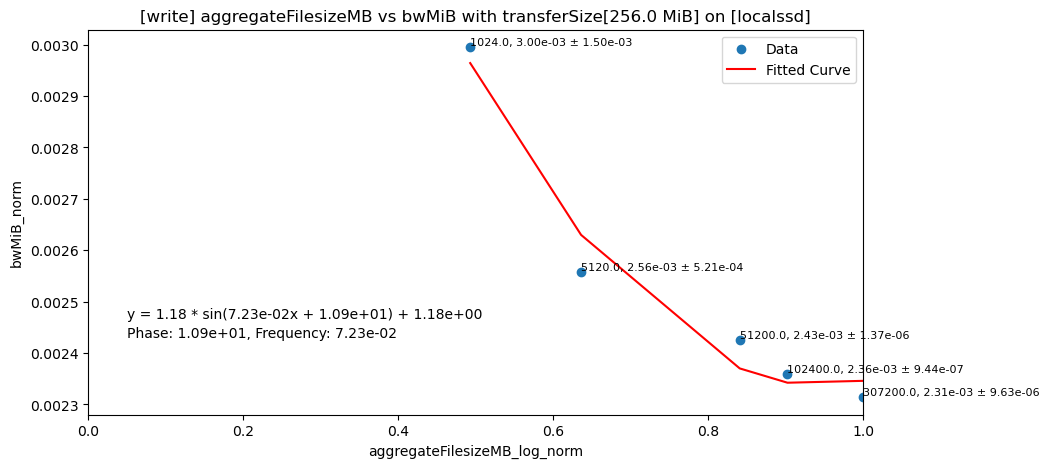

Fitted parameters: [ 6.90793883e-03  1.85918812e+01 -8.92411462e+00  1.98254696e-02]


<Figure size 640x480 with 0 Axes>

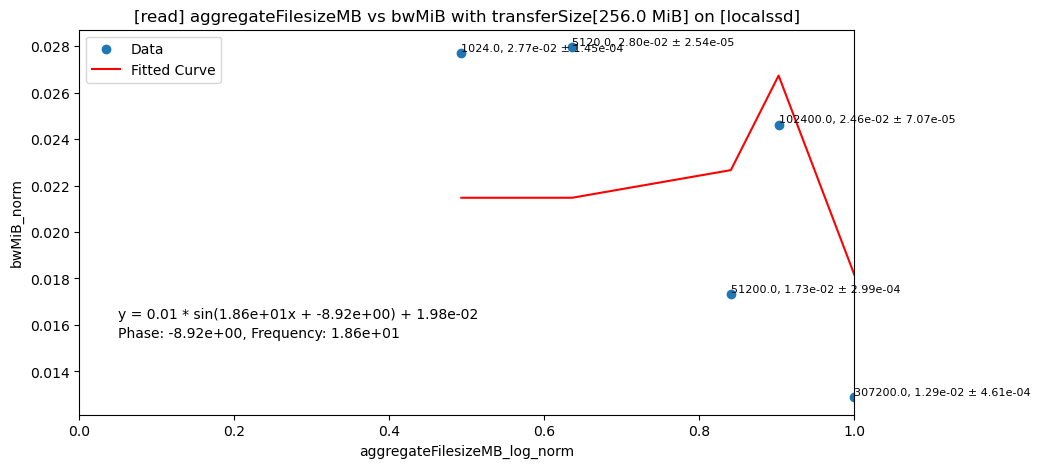

Fitted parameters: [ 4.55875657  0.06339108 10.93738736  4.56105684]


<Figure size 640x480 with 0 Axes>

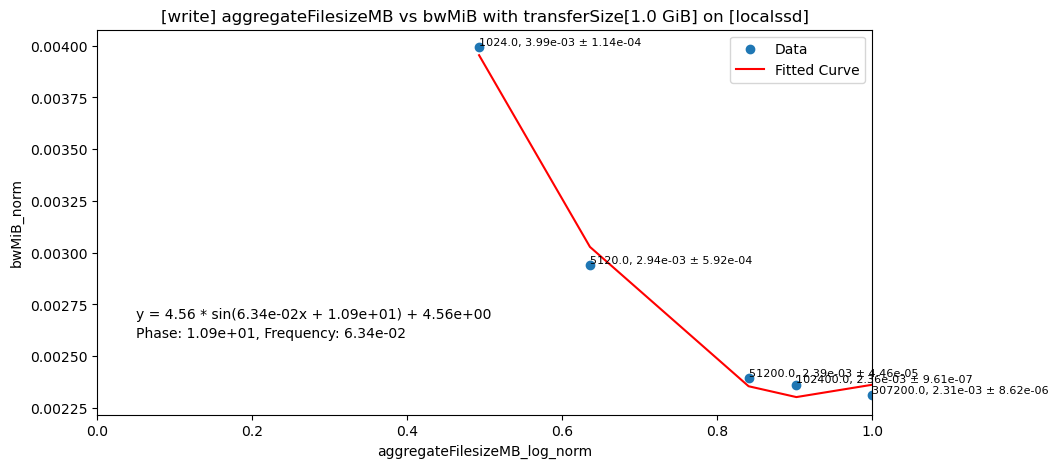

Fitted parameters: [ 16.60724966   0.09212795   7.80264127 -16.57938533]


<Figure size 640x480 with 0 Axes>

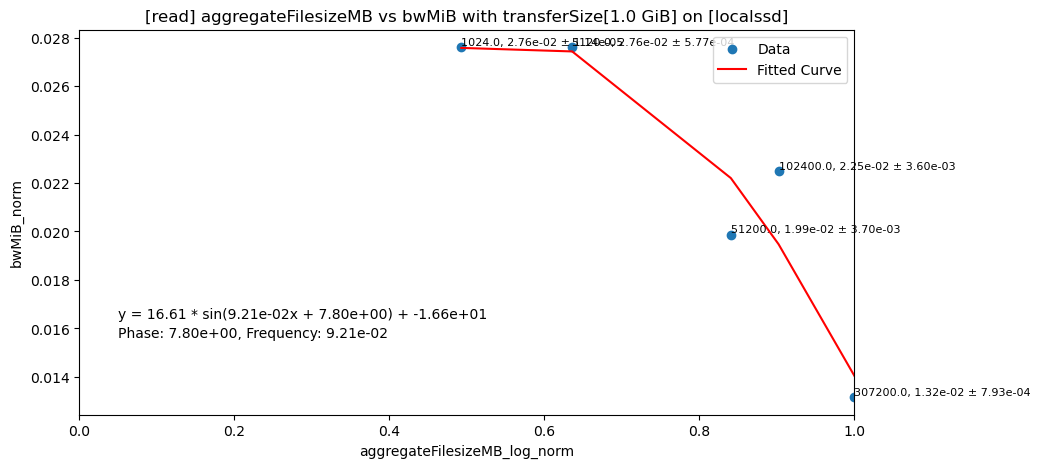

Fitted parameters: [ 9.54803816  0.08962549  1.54262421 -9.54184606]


<Figure size 640x480 with 0 Axes>

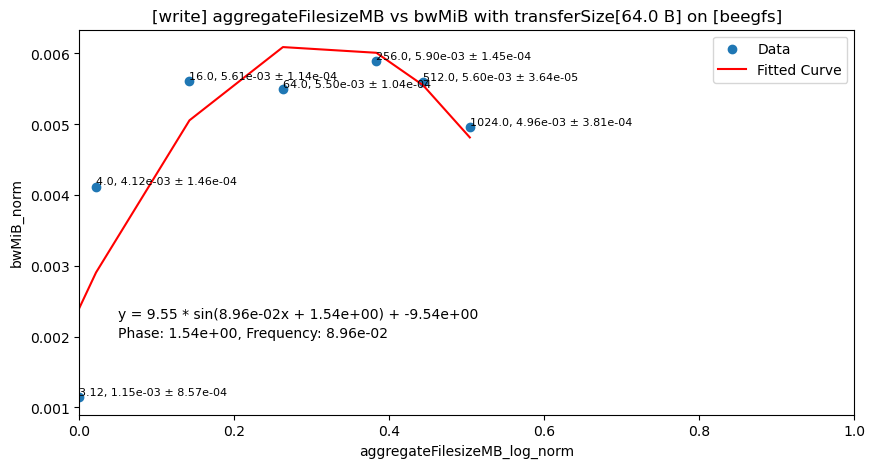

Fitted parameters: [ 6.01353509  0.10147615  1.54445131 -6.00683045]


<Figure size 640x480 with 0 Axes>

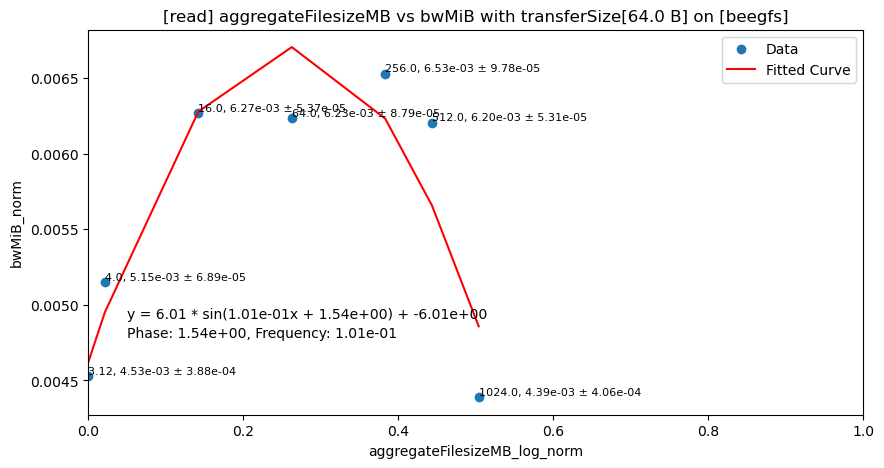

Fitted parameters: [-0.0085982   8.43062354  1.86250609  0.03864306]


<Figure size 640x480 with 0 Axes>

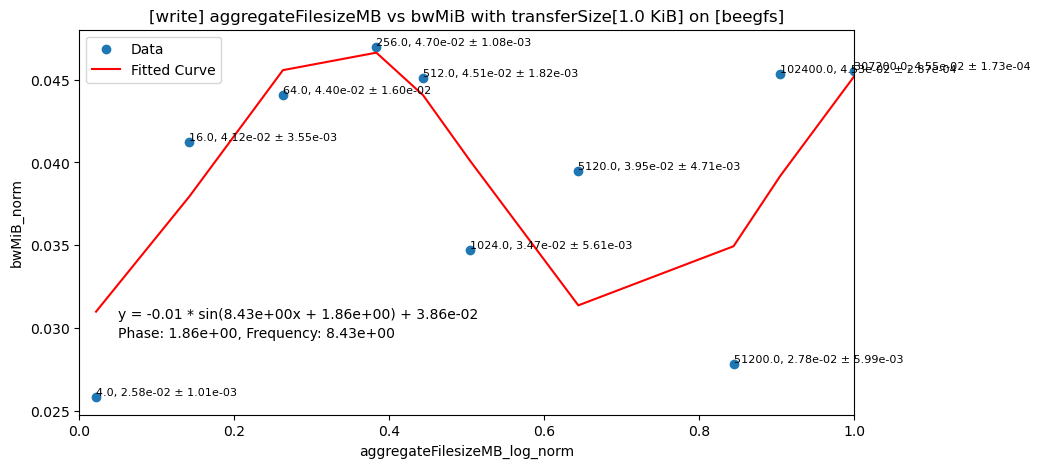

Fitted parameters: [-0.01855484  6.63321069  2.80021465  0.04118754]


<Figure size 640x480 with 0 Axes>

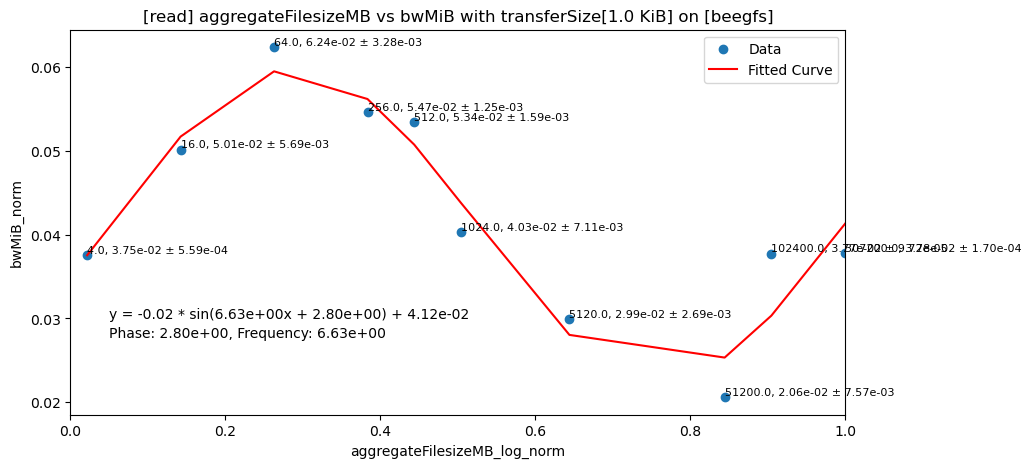

Fitted parameters: [-0.02014665  7.56116512  2.37676014  0.04393254]


<Figure size 640x480 with 0 Axes>

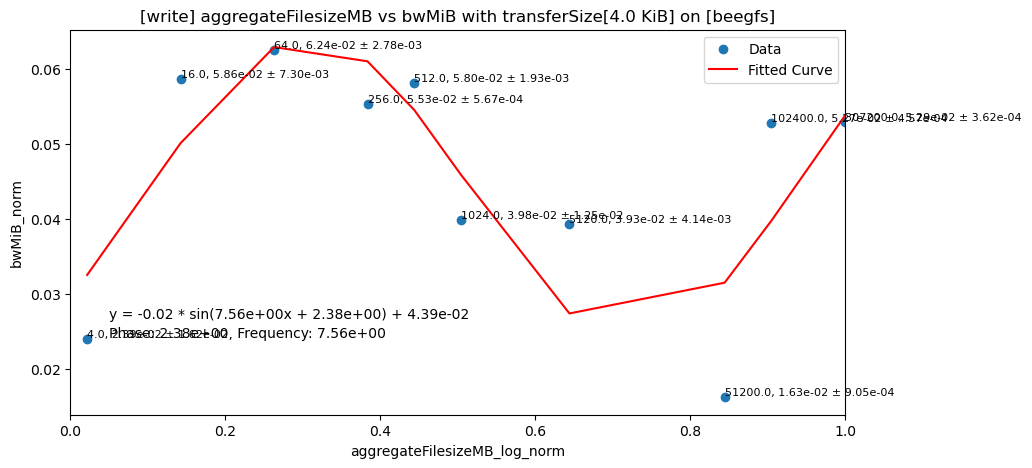

Fitted parameters: [ 0.02625211  6.20741294 -0.05938951  0.05017423]


<Figure size 640x480 with 0 Axes>

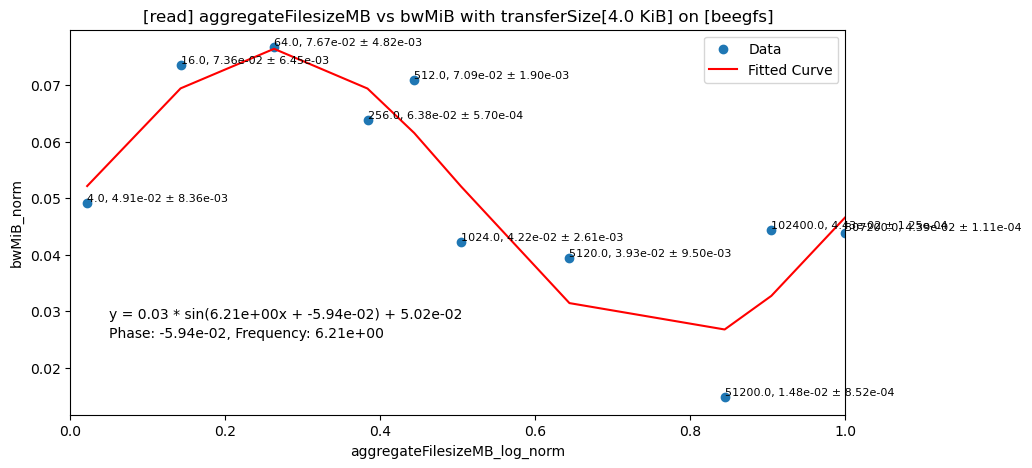

Fitted parameters: [-0.03082897  8.43916087  1.65661777  0.10348613]


<Figure size 640x480 with 0 Axes>

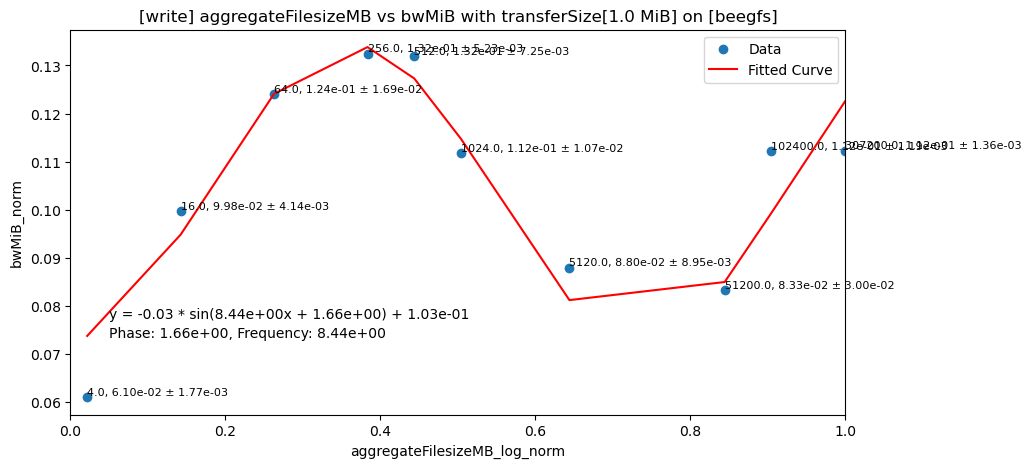

Fitted parameters: [-0.05299406  5.70449     2.82713619  0.09471757]


<Figure size 640x480 with 0 Axes>

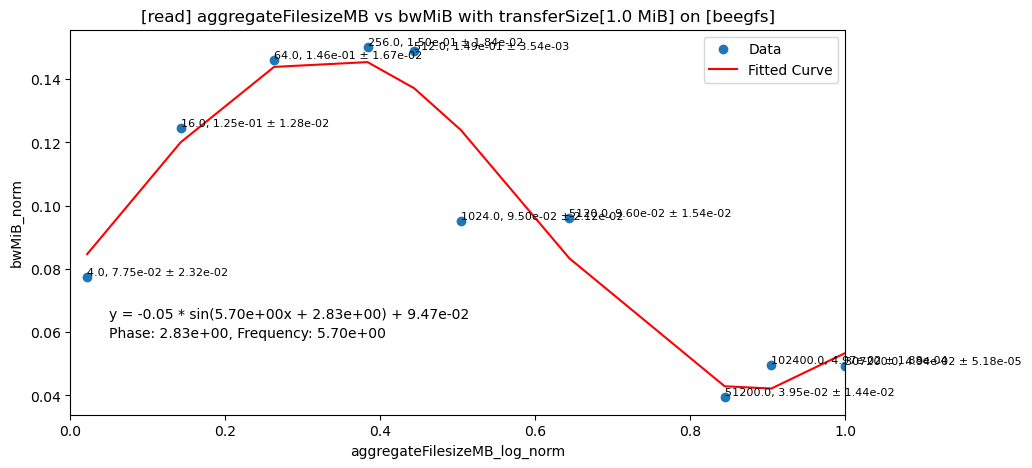

Fitted parameters: [ 6.80701452e+01  5.39428649e-02  7.75711698e+00 -6.78810995e+01]


<Figure size 640x480 with 0 Axes>

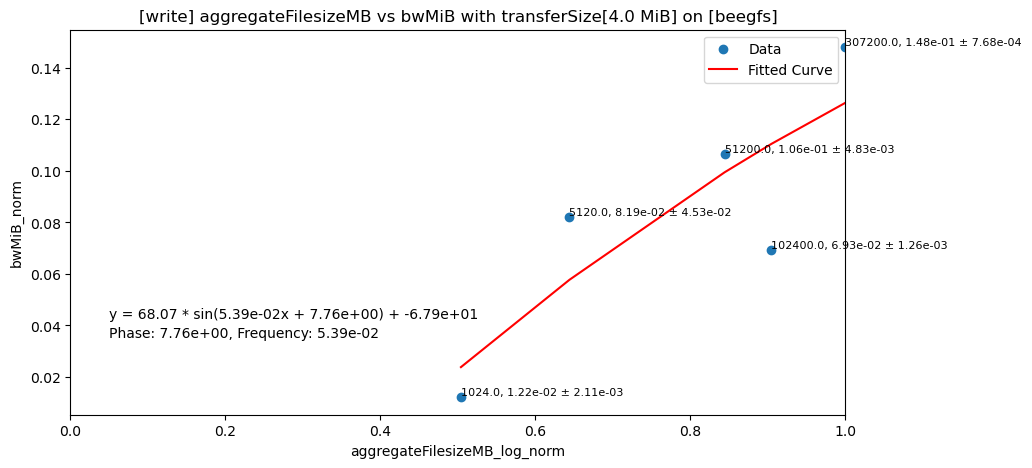

Fitted parameters: [0.04564836 9.04489289 2.8291399  0.08978087]


<Figure size 640x480 with 0 Axes>

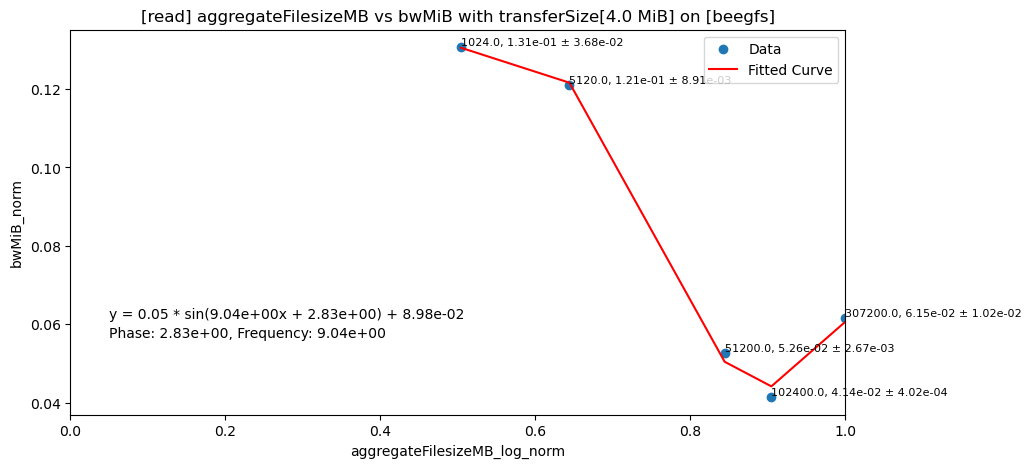

Fitted parameters: [ 9.51644884e+01  4.73014292e-02  7.77885204e+00 -9.50029526e+01]


<Figure size 640x480 with 0 Axes>

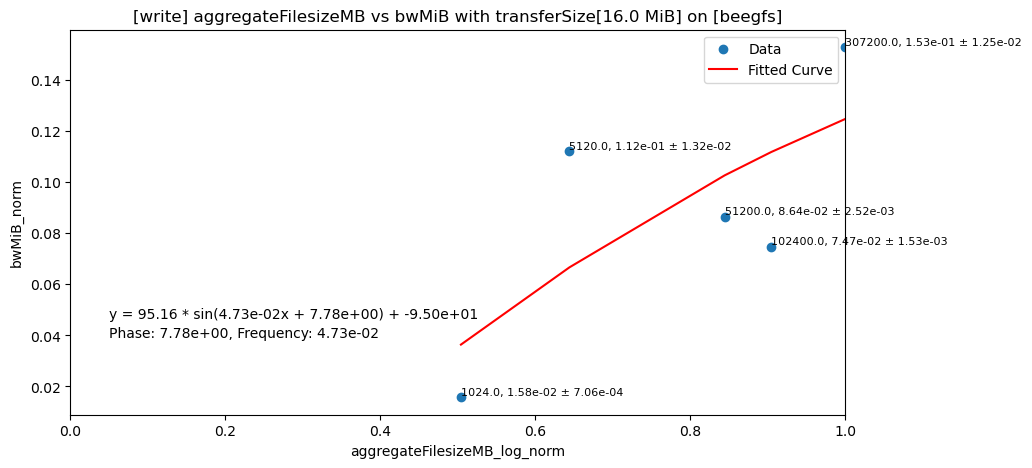

Fitted parameters: [0.0577537  9.18967161 2.85522948 0.10191594]


<Figure size 640x480 with 0 Axes>

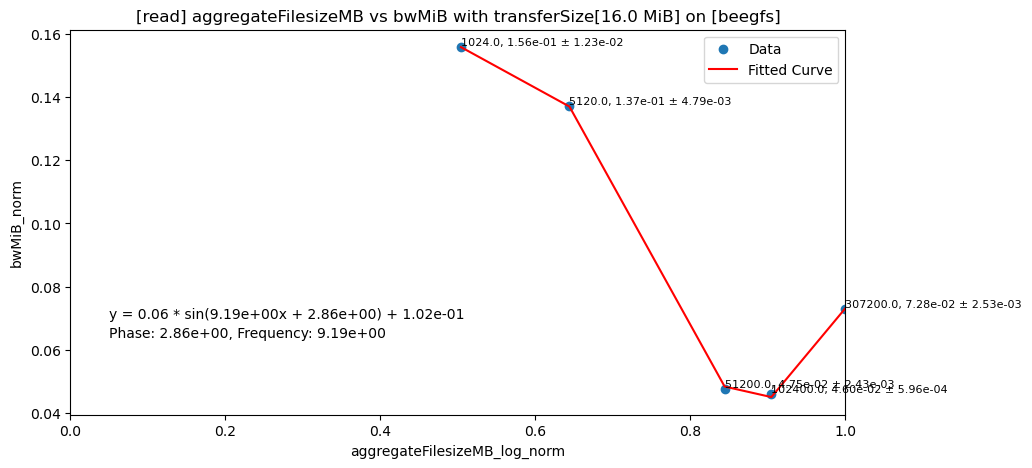

Fitted parameters: [ 7.08034835  0.05742885  7.33866669 -6.21732141]


<Figure size 640x480 with 0 Axes>

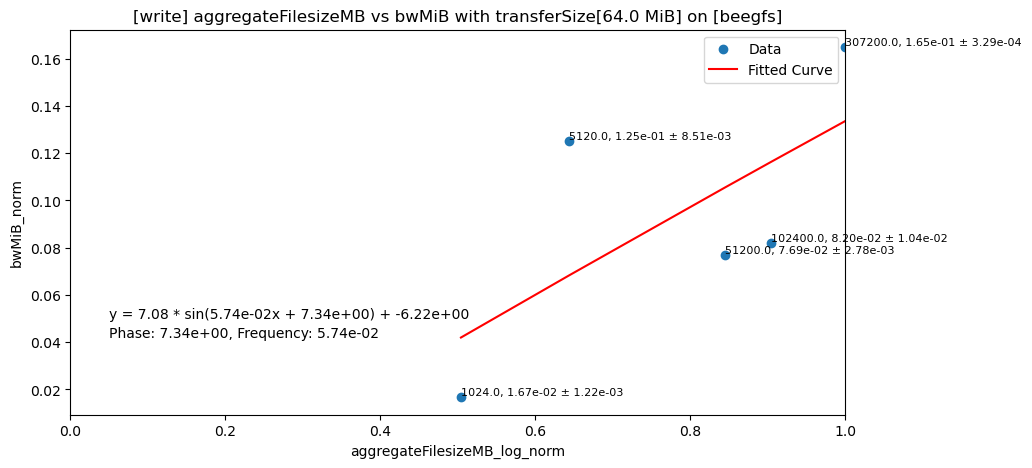

Fitted parameters: [-0.04855179 10.81177317 -1.64614852  0.0910737 ]


<Figure size 640x480 with 0 Axes>

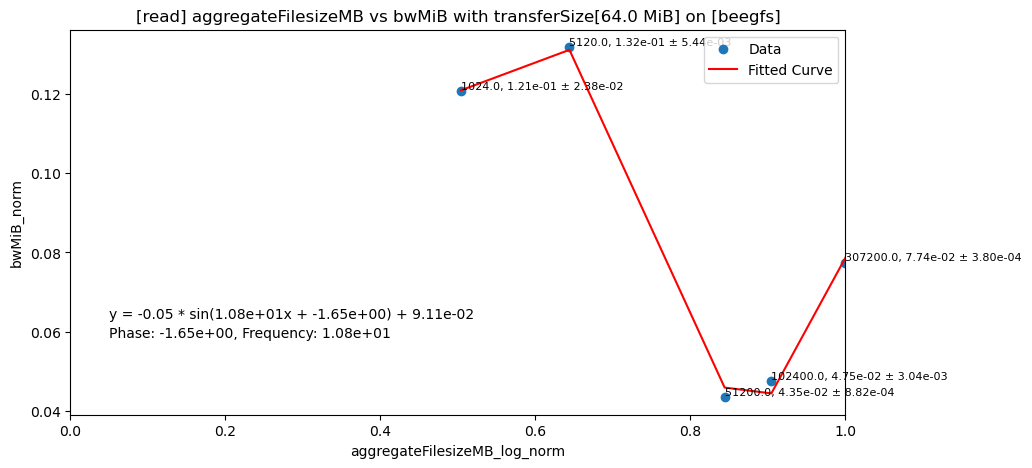

Fitted parameters: [8.51361215e+01 4.40036642e-02 4.74009928e+00 8.50654618e+01]


<Figure size 640x480 with 0 Axes>

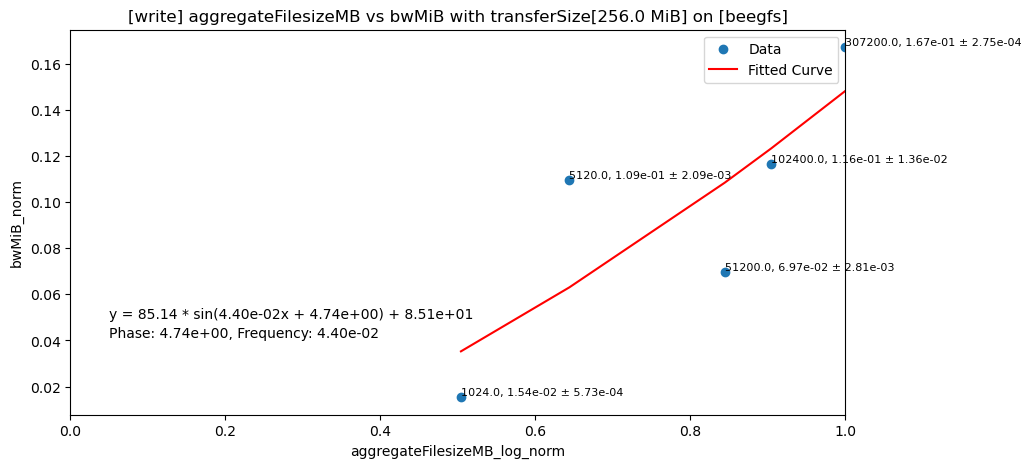

Fitted parameters: [0.04293851 9.62222868 2.69506787 0.09376619]


<Figure size 640x480 with 0 Axes>

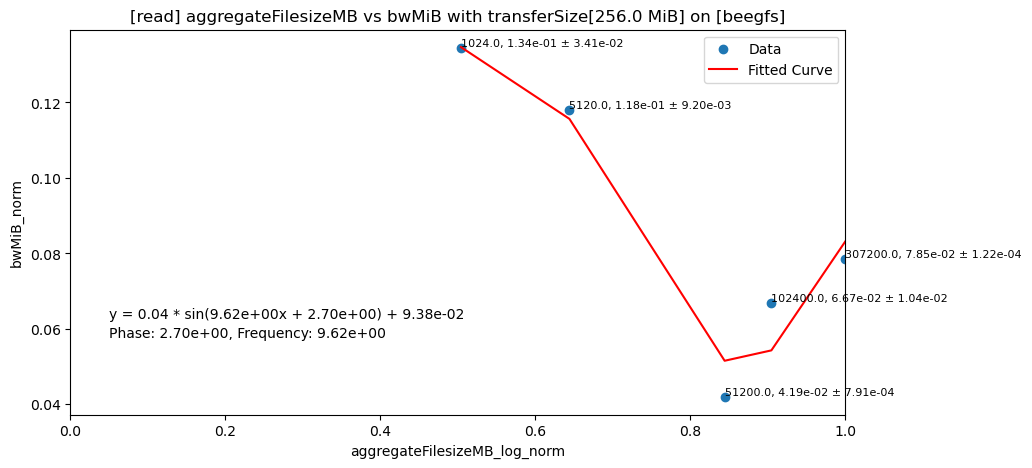

Fitted parameters: [ 6.96919955e+01  4.48248242e-02  7.74546443e+00 -6.93992542e+01]


<Figure size 640x480 with 0 Axes>

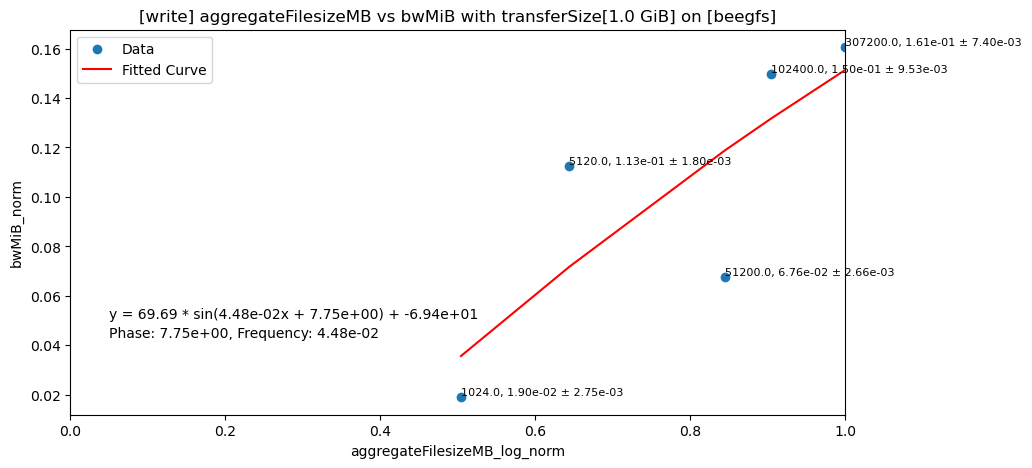

Fitted parameters: [-0.03342057 11.10884793 -1.66007614  0.08517811]


<Figure size 640x480 with 0 Axes>

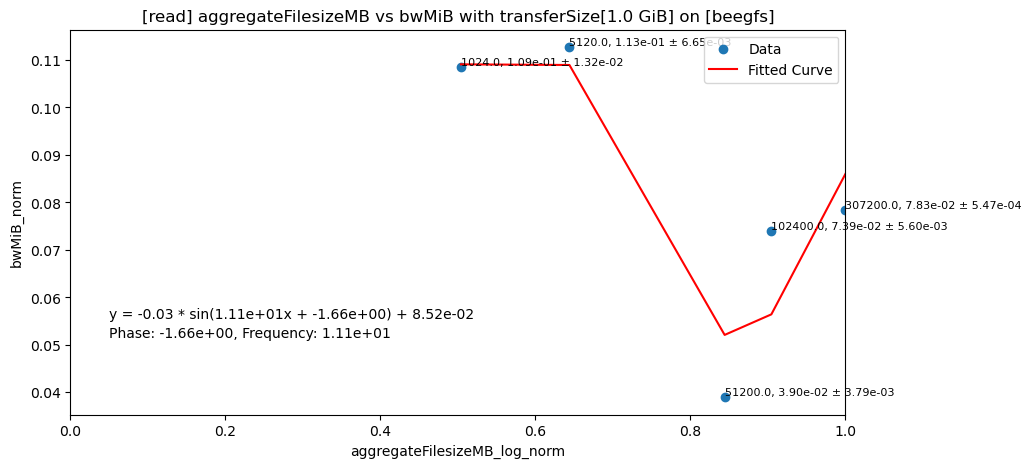

<Figure size 640x480 with 0 Axes>

In [57]:
ior_ssd_data_paths = [
        "./ior_data/localssd_ior_buffered_saved",
    "./ior_data/localssd_pior_buffered_saved",
]

ior_beegfs_data_paths = [
    "./ior_data/beegfs_ior_buffered_saved",
    "./ior_data/beegfs_pior_buffered_saved",
]




def data_paths_to_df(ior_data_paths):
    path_ior_df = pd.DataFrame(columns=IOR_PARAMS)

    for ior_data_path in ior_data_paths:
        ior_df = ior_json_to_df(ior_data_path)
        path_ior_df = path_ior_df._append(ior_df, ignore_index=True)

    cols_to_log = ['aggregateFilesizeMB', 'transferSize'] # , 'transferSize'
    cols_to_norm = ['aggregateFilesizeMB_log', 'bwMiB'] # 'transferSize', 'bwMiB'
    # normalize data
    scaled_ior_df = my_data_transform(path_ior_df, cols_to_norm=cols_to_norm, cols_to_log=cols_to_log)

    return scaled_ior_df


def analyze_df(scaled_ior_df, numTasks=1):
    # Initialize the DataFrame for storing results
    averaged_bw_df = pd.DataFrame()
    
    # Get storage type from df
    storage_code = scaled_ior_df['storageType'].unique()[0]
    storage_type = decode_store_code(storage_code)

    # Get unique transfer sizes
    xfersizes = sorted(scaled_ior_df['transferSize'].unique().tolist())

    for xfer in xfersizes:
        op_type = [0, 1]
        op_dict = {0: "write", 1: "read"}

        for op in op_type:
            # Filter the DataFrame for specific conditions
            subdf = scaled_ior_df[(scaled_ior_df['numTasks'] == numTasks) &
                                  (scaled_ior_df['transferSize'] == xfer) &
                                  (scaled_ior_df['operation'] == op)]
            
            if not subdf.empty:
                # Perform the aggregation
                ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(
                    lambda group: x_mean_std(group, 'bwMiB_norm')).reset_index()
                
                # # Calculate percentage of std deviation
                # ave_bw_df['bwMiB_norm_ave_std_perc'] = (ave_bw_df['bwMiB_norm_ave_std'] / 
                #                                         ave_bw_df['bwMiB_norm_ave']) * 100

                # # Merge the aggregated results with the original DataFrame
                # merged_df = pd.merge(subdf, ave_bw_df[['aggregateFilesizeMB_log_norm', 
                #                                        'bwMiB_norm_ave', 
                #                                        'bwMiB_norm_ave_std', 
                #                                        'bwMiB_norm_ave_std_perc']],
                #                      on='aggregateFilesizeMB_log_norm', 
                #                      how='left')
                # # Drop columns with _x
                # merged_df = merged_df.loc[:, ~merged_df.columns.str.endswith('_x')]
                # # Rename columns with _y
                # merged_df.columns = merged_df.columns.str.replace('_y', '')
                
                # # Append the merged DataFrame to the results DataFrame
                # averaged_bw_df = pd.concat([averaged_bw_df, merged_df], ignore_index=True)

                # Plotting (as before)
                y_datalabel = [f"{y:.2e} ± {y_std:.2e}" for y, y_std in zip(
                    ave_bw_df['bwMiB_norm_ave'], ave_bw_df['bwMiB_norm_ave_std'])]
                
                _oscillatory_trend(
                    ave_bw_df['aggregateFilesizeMB_log_norm'], 
                    ave_bw_df['bwMiB_norm_ave'], 
                    x_label="aggregateFilesizeMB_log_norm", 
                    y_label="bwMiB_norm",
                    title=f"[{op_dict[op]}] aggregateFilesizeMB vs bwMiB with transferSize[{byte_size_to_human_size(xfer)}] on [{storage_type}]", 
                    show=True, x_datalabel=sorted(subdf['aggregateFilesizeMB'].unique().tolist()), y_datalabel=y_datalabel,
                    save_path="./seq_graph"
                )

    # return averaged_bw_df


ssd_df = data_paths_to_df(ior_ssd_data_paths)
beegfs_df = data_paths_to_df(ior_beegfs_data_paths)

print(ssd_df.head(5))
print(beegfs_df.head(5))

analyze_df(ssd_df, numTasks=1)
analyze_df(beegfs_df, numTasks=1)


# master_ior_df.to_csv("master_ior_df.csv")

In [58]:
# # Select df with std > 27
# ssd_sel_df = ssd_df[ssd_df['bwMiB_ave_std_perc'] > 27]
# beegfs_sel_df = beegfs_df[beegfs_df['bwMiB_ave_std_perc'] > 27]
# print(f"Original SSD DF [{ssd_df.shape}] to [{ssd_sel_df.shape}]")
# print(ssd_sel_df.head(2))
# print(f"Original BeeGFS DF [{beegfs_df.shape}] to [{beegfs_sel_df.shape}]")
# print(beegfs_sel_df.head(2))

# Show the 95th percentile of the bwMiB_ave_std_perc column
print("95th percentile of bwMiB_ave_std_perc column:")
print(f"SSD: {ssd_df['bwMiB_ave_std_perc'].quantile(0.95)}")
print(f"BeeGFS: {beegfs_df['bwMiB_ave_std_perc'].quantile(0.95)}")

# Show the 85th percentile of the bwMiB_ave_std_perc column
print("85th percentile of bwMiB_ave_std_perc column:")
print(f"SSD: {ssd_df['bwMiB_ave_std_perc'].quantile(0.85)}")
print(f"BeeGFS: {beegfs_df['bwMiB_ave_std_perc'].quantile(0.85)}")

# Select sequential read/write operations
ssd_seq_df = ssd_df[ssd_df['numTasks'] == 1]
beegfs_seq_df = beegfs_df[beegfs_df['numTasks'] == 1]
print(f"Sequential SSD DF: {ssd_seq_df.shape}")
print(f"Sequential BeeGFS DF: {beegfs_seq_df.shape}")
# Show the 95th percentile of the bwMiB_ave_std_perc column
print("95th percentile of bwMiB_ave_std_perc column for sequential operations:")
print(f"SSD: {ssd_seq_df['bwMiB_ave_std_perc'].quantile(0.95)}")
print(f"BeeGFS: {beegfs_seq_df['bwMiB_ave_std_perc'].quantile(0.95)}")

# Show the 85th percentile of the bwMiB_ave_std_perc column
print("85th percentile of bwMiB_ave_std_perc column for sequential operations:")
print(f"SSD: {ssd_seq_df['bwMiB_ave_std_perc'].quantile(0.85)}")
print(f"BeeGFS: {beegfs_seq_df['bwMiB_ave_std_perc'].quantile(0.85)}")




95th percentile of bwMiB_ave_std_perc column:
SSD: 18.945794742635464
BeeGFS: 27.9129750374208
85th percentile of bwMiB_ave_std_perc column:
SSD: 10.46696231744693
BeeGFS: 15.339444898049972
Sequential SSD DF: (378, 17)
Sequential BeeGFS DF: (372, 17)
95th percentile of bwMiB_ave_std_perc column for sequential operations:
SSD: 18.740854012679655
BeeGFS: 28.129782620465356
85th percentile of bwMiB_ave_std_perc column for sequential operations:
SSD: 9.509071468329518
BeeGFS: 14.430386582458702


In [59]:
# Select sequential read/write that has bwMiB_ave_std_perc > perc
perc = 20
ssd_seq_sel_df = ssd_seq_df[ssd_seq_df['bwMiB_ave_std_perc'] > perc]
beegfs_seq_sel_df = beegfs_seq_df[beegfs_seq_df['bwMiB_ave_std_perc'] > perc]
print(f"Sequential SSD DF with bwMiB_ave_std_perc > {perc}: {ssd_seq_sel_df.shape}")
print(ssd_seq_sel_df)
print(f"Sequential BeeGFS DF with bwMiB_ave_std_perc > {perc}: {beegfs_seq_sel_df.shape}")
print(beegfs_seq_sel_df)


Sequential SSD DF with bwMiB_ave_std_perc > 20: (15, 17)
      operation  randomOffset  transferSize  aggregateFilesizeMB  numTasks  \
726         0.0           0.0     4194304.0               1024.0       1.0   
727         0.0           0.0     4194304.0             102400.0       1.0   
728         0.0           0.0     4194304.0               1024.0       1.0   
729         0.0           0.0     4194304.0              51200.0       1.0   
730         0.0           0.0     4194304.0              51200.0       1.0   
733         0.0           0.0     4194304.0               5120.0       1.0   
734         0.0           0.0     4194304.0             102400.0       1.0   
735         0.0           0.0     4194304.0               5120.0       1.0   
736         0.0           0.0     4194304.0               5120.0       1.0   
738         0.0           0.0     4194304.0              51200.0       1.0   
739         0.0           0.0     4194304.0             102400.0       1.0   
740    

In [60]:
def merge_by_test_param(ssd_df, beegfs_df):
    # Compare and find the row with only storage_type and bwMiB columns different but others are the same
    # Merge the dataframes on columns other than 'storageType' and 'bwMiB'
    merge_columns = ['operation', 'randomOffset', 'transferSize', 'aggregateFilesizeMB', 'numTasks', 'numNodes', 'tasksPerNode'] # 'totalTime', 
    merged_df = pd.merge(ssd_df, beegfs_df, on=merge_columns, suffixes=('_ssd', '_beegfs'))

    # Remove columns storageType_ssd and storageType_beegfs
    merged_df.drop(['storageType_ssd', 'storageType_beegfs'], axis=1, inplace=True)

    # Compare 'bwMiB' values and add 'selectStorage' column
    merged_df['selectStorage'] = merged_df.apply(lambda row: 0 if row['bwMiB_ssd'] > row['bwMiB_beegfs'] else 1, axis=1)


    print(merged_df.head(5))
    # print shaoe
    print(f"merged_df.shape: {merged_df.shape}")
    print(f"ssd_df.shape: {ssd_df.shape}")
    print(f"beegfs_df.shape: {beegfs_df.shape}")

    return merged_df


master_ior_df = merge_by_test_param(ssd_df, beegfs_df)

# Save the merged DataFrame to a CSV file
master_ior_df.to_csv("master_ior_df.csv")

# Show 5 rows with selectStorage = 0
print(f"Rows with selectStorage = {decode_store_code(0)}")
print(master_ior_df[master_ior_df['selectStorage'] == 0].head(5))

# Show 5 rows with selectStorage = 1
print(f"Rows with selectStorage = {decode_store_code(1)}")
print(master_ior_df[master_ior_df['selectStorage'] == 1].head(5))

# Get unique transferSize in both ssd and beegfs and show them without scientific notation
XferSize = sorted(master_ior_df['transferSize'].unique().tolist())
print(f"Unique transferSizes: {XferSize}")



   operation  randomOffset  transferSize  aggregateFilesizeMB  numTasks  \
0        0.0           0.0          64.0               1024.0       1.0   
1        0.0           0.0          64.0               1024.0       1.0   
2        0.0           0.0          64.0               1024.0       1.0   
3        0.0           0.0          64.0               1024.0       1.0   
4        0.0           0.0          64.0               1024.0       1.0   

   totalTime_ssd  numNodes  tasksPerNode  bwMiB_ssd  bwMiB_ave_ssd  ...  \
0        19.2664       1.0           1.0    53.1495        52.8634  ...   
1        19.2664       1.0           1.0    53.1495        52.8634  ...   
2        19.2664       1.0           1.0    53.1495        52.8634  ...   
3        19.5916       1.0           1.0    52.2673        52.8634  ...   
4        19.5916       1.0           1.0    52.2673        52.8634  ...   

   totalTime_beegfs  bwMiB_beegfs  bwMiB_ave_beegfs  bwMiB_ave_std_beegfs  \
0            9.5727  

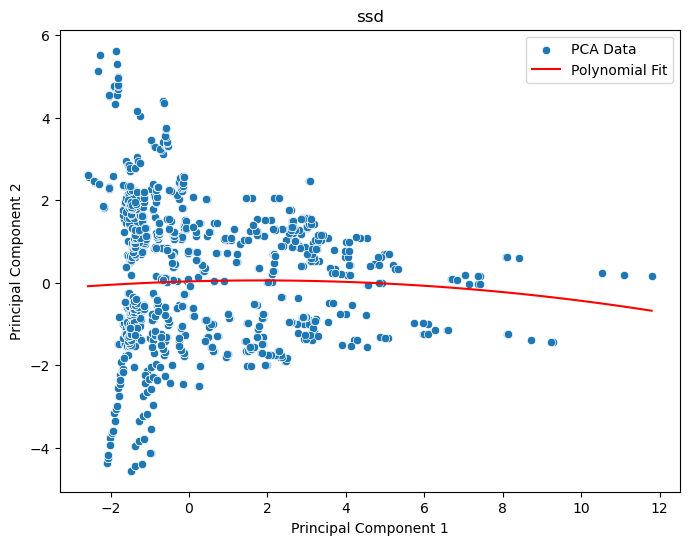

Polynomial fit parameters: a=-0.007346385728807782, b=0.026435176316638793, c=0.03073827616452226
Reconstruction error (MSE): 0.395303141335983
Explained variance by principal components: [0.29886654 0.2211225 ]


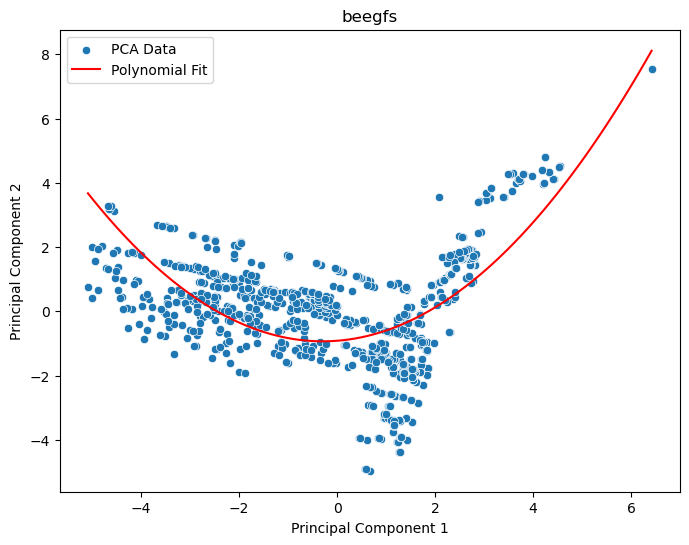

Polynomial fit parameters: a=0.2008099886539101, b=0.11841551780076245, c=-0.9176170052981716
Reconstruction error (MSE): 0.3682044708670571
Explained variance by principal components: [0.32639846 0.22649611]


/people/tang584/.conda/envs/pyflextrkr/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


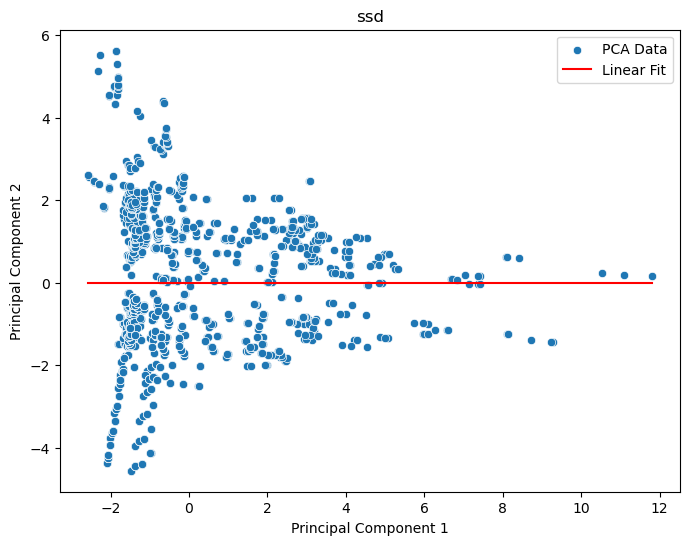

Linear fit parameters: intercept=-8.181379173516269e-33, slope=1.3759549736151064e-16
Reconstruction error (MSE): 0.39530314133598304
Explained variance by principal components: [0.29886654 0.2211225 ]


/people/tang584/.conda/envs/pyflextrkr/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


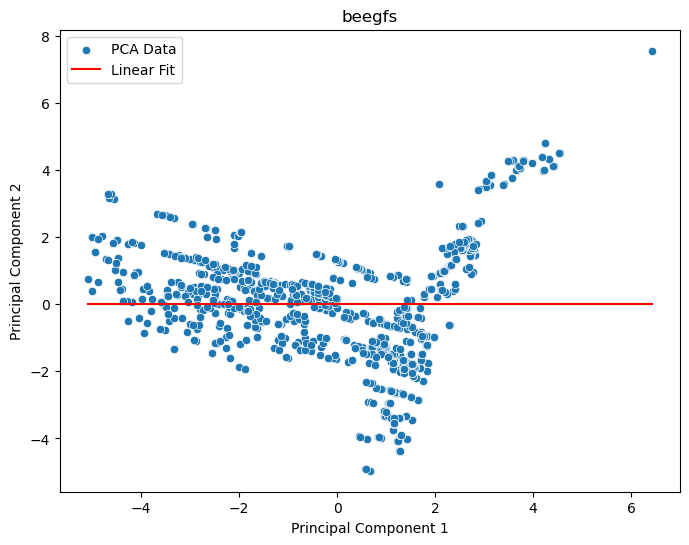

Linear fit parameters: intercept=6.260288420793835e-17, slope=-4.825999422908753e-17
Reconstruction error (MSE): 0.36820447086705704
Explained variance by principal components: [0.32639846 0.22649611]


In [61]:
# select only storage type of 0
_polynomial_fit_pca(ssd_df, title="ssd")
_polynomial_fit_pca(beegfs_df, title="beegfs")
_linear_fit_pca(ssd_df, title="ssd")
_linear_fit_pca(beegfs_df, title="beegfs")



In [72]:
def is_sequential(numbers):
    if not numbers:  # Check if the list is empty
        return False

    sorted_numbers = sorted(numbers)  # Sort the numbers
    return all(sorted_numbers[i] + 1 == sorted_numbers[i + 1] for i in range(len(sorted_numbers) - 1))

def get_wf_result_df(tests, wf_params, target_tasks, 
                     numTasksWrite=1, numTasksRead=1, numNodes=1, storageType="localssd"):

    wf_df = pd.DataFrame(columns=wf_params)

    # Find folders ending with [t1, t2, t3] in the test_folders
    test_folders = glob.glob(f"{tests}/*")
    wf_trial_folders = [folder for folder in test_folders if folder.endswith("t1") or folder.endswith("t2") or folder.endswith("t3")]
    # print(f"Found trial folders: {wf_trial_folders} ")

    store_code = transform_store_code(storageType)
    
    for trial_folder in wf_trial_folders:
        # Find all json files in the trial folder
        # wf_json_files = glob.glob(f"{trial_folder}/*.json")


        datalife_jsons = glob.glob(f"{trial_folder}/*.datalife.json")

        # print(datalife_jsons)

        monitor_timer_stat = {}


        for datalife_json in datalife_jsons:
            with open(datalife_json) as f:
                datalife_data = json.load(f)
                # Get the first key
                task_name = list(datalife_data.keys())[0]

                # check if the task is in the target_tasks, or part of the target_tasks substring
                if any(task in task_name for task in target_tasks):
                    # print(f"Found task [{task_name}]")
                    # Select 'monitor', not 'system' and 'local'
                    monitor_timer_stat = datalife_data[task_name]['monitor']
                    # TODO: get one forf now
                    break
        # print(monitor_timer_stat)

        # Get write statistics
        monitor_timer_stat_write = monitor_timer_stat['write'] # list with [time_sec, op_cnt, io_size]
        print(f"monitor_timer_stat_write = {monitor_timer_stat_write}")
        tmp_write_stat = {}
        tmp_write_stat['aggregateFilesizeMB'] = file_size_to_mb(monitor_timer_stat_write[2])
        tmp_write_stat['numTasks'] = numTasksWrite
        tmp_write_stat['numNodes'] = numNodes
        tmp_write_stat['tasksPerNode'] = tmp_write_stat['numNodes']/tmp_write_stat['numTasks']
        tmp_write_stat['transferSize'] = monitor_timer_stat_write[2]/monitor_timer_stat_write[1]
        tmp_write_stat['operation'] = 0
        tmp_write_stat['totalTime'] = monitor_timer_stat_write[0]
        tmp_write_stat['bwMiB'] = monitor_timer_stat_write[2]/monitor_timer_stat_write[0]
        tmp_write_stat['storageType'] = store_code

        w_blk_trace_jsons = glob.glob(f"{trial_folder}/*w_blk_trace.json")
        write_pattern = 0 # 0: seq, 1: rand        
        for w_blk_trace_json in w_blk_trace_jsons:
            with open(w_blk_trace_json) as f:
                w_blk_trace_data = json.load(f)
                # print(w_blk_trace_data)
                blk_list = w_blk_trace_data['io_blk_range']
                if not is_sequential(blk_list):
                    write_pattern =1
                    # For now only single read and write
                    break
        tmp_write_stat['randomOffset'] = write_pattern
        wf_df = wf_df._append(tmp_write_stat, ignore_index=True)

        # Get read statistics
        monitor_timer_stat_read = monitor_timer_stat['read']
        tmp_read_stat = {}
        tmp_read_stat['aggregateFilesizeMB'] = file_size_to_mb(monitor_timer_stat_read[2])
        tmp_read_stat['numTasks'] = numTasksRead
        tmp_read_stat['numNodes'] = numNodes
        tmp_read_stat['tasksPerNode'] = tmp_read_stat['numNodes']/tmp_read_stat['numTasks']
        tmp_read_stat['transferSize'] = monitor_timer_stat_read[2]/monitor_timer_stat_read[1]
        tmp_read_stat['operation'] = 1
        tmp_read_stat['totalTime'] = monitor_timer_stat_read[0]
        tmp_read_stat['bwMiB'] = monitor_timer_stat_read[2]/monitor_timer_stat_read[0]
        tmp_read_stat['storageType'] = store_code

        r_blk_trace_jsons = glob.glob(f"{trial_folder}/*r_blk_trace.json")
        read_pattern = 0
        for r_blk_trace_json in r_blk_trace_jsons:
            with open(r_blk_trace_json) as f:
                r_blk_trace_data = json.load(f)
                blk_list = r_blk_trace_data['io_blk_range']
                if not is_sequential(blk_list):
                    read_pattern =1
                    # For now only single read and write
                    break
        tmp_read_stat['randomOffset'] = read_pattern
        wf_df = wf_df._append(tmp_read_stat, ignore_index=True)

    # encode string to numbers
    le = preprocessing.LabelEncoder()
    for col in wf_df.columns:
        if pd.api.types.is_string_dtype(wf_df[col]):
            wf_df[col] = le.fit_transform(wf_df[col])

    # print(wf_df.head(5))

    return wf_df

In [73]:
# Load 1kgenome data
onekg_data_path = "./1kgenome_data/1000_tests"



# Key Parameters
wf_params = ['operation', 'randomOffset', 'transferSize', 
            'aggregateFilesizeMB', 'numTasks', 'totalTime', 
            'numNodes', 'tasksPerNode', 'bwMiB', "storageType"]
target_tasks = ["python"] # omit srun from 1kgenome run

all_wf_df = pd.DataFrame(columns=wf_params)

def get_test_folder_dfs(test_folder, wf_params, target_tasks, 
                        storageType="localssd"):
    folder_dfs = pd.DataFrame(columns=wf_params)

    for tests in test_folder:
        # check of test folder starts with seq or par
        if tests.startswith("seq"):
            numTasksWrite = 1
            numTasksRead = 1
        else:
            # get the number after _ps
            num_tasks = int(tests.split("_")[-1].split("ps")[1])
            numTasksWrite = num_tasks
            numTasksRead = num_tasks

        # io_size_dfs
        wf_df = get_wf_result_df(f"{onekg_data_path}/{tests}", wf_params, target_tasks, 
                                numTasksWrite=numTasksWrite, numTasksRead=numTasksRead, 
                                storageType=storageType)
        # print(wf_df.head(5))
        # # Print size of df
        # print(f"df shape: {wf_df.shape}")

        # corr_matrix(wf_df, storageType)
        folder_dfs = folder_dfs._append(wf_df, ignore_index=True)
    return folder_dfs

wf_ssd_df = pd.DataFrame(columns=wf_params)
seq_test_folder = ['seq_1000_1n_ssd_ps1', 'seq_1000_1n_ssd_ps2', 
                'seq_1000_1n_ssd_ps20','seq_1000_1n_ssd_ps40']
wf_ssd_df = wf_ssd_df._append(get_test_folder_dfs(seq_test_folder, 
                                        wf_params, target_tasks, 
                                        storageType="localssd"), ignore_index=True)



par_test_folder = ['par_1000_1n_ssd_ps1','par_1000_1n_ssd_ps2',
                'par_1000_1n_ssd_ps20','par_1000_1n_ssd_ps40']
wf_ssd_df = wf_ssd_df._append(get_test_folder_dfs(par_test_folder,
                                        wf_params, target_tasks, 
                                        storageType="localssd"), ignore_index=True)


wf_beegfs_df = pd.DataFrame(columns=wf_params)
seq_pfs_test_folder = ['seq_1000_1n_pfs_ps1', 'seq_1000_1n_pfs_ps2',
                       'seq_1000_1n_pfs_ps20','seq_1000_1n_pfs_ps40']
wf_beegfs_df = wf_beegfs_df._append(get_test_folder_dfs(seq_pfs_test_folder,
                                        wf_params, target_tasks, 
                                        storageType="beegfs"), ignore_index=True)


par_test_folder = ['par_1000_1n_pfs_ps1','par_1000_1n_pfs_ps2',
                'par_1000_1n_pfs_ps20','par_1000_1n_pfs_ps40']
wf_beegfs_df = wf_beegfs_df._append(get_test_folder_dfs(par_test_folder,
                                        wf_params, target_tasks, 
                                        storageType="beegfs"), ignore_index=True)






monitor_timer_stat_write = [5.0692e-05, 4, 31245]
monitor_timer_stat_write = [4.3199e-05, 4, 31088]
monitor_timer_stat_write = [4.504e-05, 4, 31093]
monitor_timer_stat_write = [5.2022e-05, 4, 31102]
monitor_timer_stat_write = [4.6989e-05, 4, 31375]
monitor_timer_stat_write = [4.8343e-05, 4, 31179]
monitor_timer_stat_write = [4.8401e-05, 4, 62093]
monitor_timer_stat_write = [6.3693e-05, 4, 31243]
monitor_timer_stat_write = [6.0188e-05, 4, 48348]
monitor_timer_stat_write = [4.691e-05, 4, 30995]
monitor_timer_stat_write = [5.534e-05, 4, 48224]
monitor_timer_stat_write = [5.148e-05, 4, 49350]
monitor_timer_stat_write = [5.7939e-05, 4, 31071]
monitor_timer_stat_write = [5.603e-05, 4, 31083]
monitor_timer_stat_write = [5.1729e-05, 4, 31145]
monitor_timer_stat_write = [6.3412e-05, 4, 31022]
monitor_timer_stat_write = [6.6802e-05, 4, 31153]
monitor_timer_stat_write = [6.1101e-05, 4, 31115]
monitor_timer_stat_write = [5.0001e-05, 4, 52977]
monitor_timer_stat_write = [4.9592e-05, 4, 56491]
monit

In [74]:


all_wf_df = merge_by_test_param(wf_ssd_df, wf_beegfs_df)

all_wf_df.to_csv("1000_1n_ssd_pfs.csv")

scaled_wf_ssd_df = my_data_transform(wf_ssd_df, cols_to_norm=['aggregateFilesizeMB', 'bwMiB'])
scaled_wf_beegfs_df = my_data_transform(wf_beegfs_df, cols_to_norm=['aggregateFilesizeMB', 'bwMiB'])
# concat the two dfs
scaled_wf_df = pd.concat([scaled_wf_ssd_df, scaled_wf_beegfs_df], ignore_index=True)

scaled_wf_df.to_csv("1000_1n_ssd_pfs_scaled.csv")

   operation  randomOffset  transferSize  aggregateFilesizeMB  numTasks  \
0        1.0           1.0    8191.91228               2421.0       1.0   
1        1.0           1.0    8191.91228               2421.0       1.0   
2        1.0           1.0    8191.91228               2421.0       1.0   
3        1.0           1.0    8191.91228               2421.0       1.0   
4        1.0           1.0    8191.91228               2421.0       1.0   

   totalTime_ssd  numNodes  tasksPerNode     bwMiB_ssd  totalTime_beegfs  \
0       0.575886       1.0           1.0  4.409683e+09          6.772069   
1       0.575886       1.0           1.0  4.409683e+09        110.898272   
2       0.575886       1.0           1.0  4.409683e+09          5.103058   
3       0.575886       1.0           1.0  4.409683e+09          4.549485   
4       0.575886       1.0           1.0  4.409683e+09          5.400382   

   bwMiB_beegfs  selectStorage  
0  3.749927e+08              0  
1  2.289915e+07           

In [75]:
# TODO: Add a expected memory access time to get the expected best bwMiB
# A dictionary with expected file size limit and the expected memory access performance, then time
# DDR4-2400	DDR4-2400 Peak Transfer Rate 19.2GB/s
# Maximum Memory Speed 2400 MHz	
# Max # of Memory Channels: 6
# Total Bandwidth=19.2GB/s * 6 = 115.2GB/s
# https://docs.google.com/spreadsheets/d/1eHgRg3jEjf00q9l6CXmOAyeirnDOXOlM2DUrSAJvKTc/edit?gid=1374170985#gid=1374170985

mem_access_dictMB = {
    # 25GB expressed in MB size, then {IO_size: [bwGB/s, readTimeSec, writeTimeSec] } 
    25600: {
        # 64 bytes read is 2.6 times write performance speed
        64: [115.2, 0.222, 0.085], 
        # 1KB read is 4.5 times write performance speed
        1024: [115.2, 0.222, 0.049],
        # 4KB read is 7 times write performance speed
        4096: [115.2, 0.222, 0.032],
        # 1MB read is 10 times write performance speed
        1048576: [115.2, 0.222, 0.022],
        # 4MB read is 14 times write performance speed
        4194304: [115.2, 0.222, 0.016],
        # 64MB read is 8 times write performance speed
        67108864: [115.2, 0.222, 0.028],
        # 1GB read is 7 times write performance speed
        1073741824: [115.2, 0.222, 0.032],
    },
    # 256GB expressed in MB size, then {IO_size: [bwGB/s, readTimeSec, writeTimeSec] }
    262144: {
        # 1KB read is 4 times write performance speed
        1024: [115.2, 0.222, 0.055],
        # 4KB read is 8 times write performance speed
        4096: [115.2, 0.222, 0.028],
        # 1MB read is 11 times write performance speed
        1048576: [115.2, 0.222, 0.020],
        # 4MB read is 15 times write performance speed
        4194304: [115.2, 0.222, 0.015],
        # 64MB read is 7 times write performance speed
        67108864: [115.2, 0.222, 0.032],
        # 1GB read is 7 times write performance speed
        1073741824: [115.2, 0.222, 0.032],
    }
}

# Calculated the expected bwMiB for the given file size and xferSize
# iterate through the df and calculate the expected bwMiB
for index, row in all_wf_df.iterrows():
    # Get the file size in MB
    filesize = row['aggregateFilesizeMB']
    # Get the transfer size in MB
    xferSize = row['transferSize']
    # Get the operation
    operation = row['operation']
    # # Get the storageType
    # storageType = row['storageType']

    # Determine the file size
    fileSizeList = sorted(list(mem_access_dictMB.keys()))
    # Pick the file size that is greater than the filesize
    for i, fs in enumerate(fileSizeList):
        if fs > filesize:
            # Get the previous file size
            pick_filesize = fs

    # Find the range of xferSize and tage the linear rate of bwGBs
    xferSizeList = sorted(list(mem_access_dictMB[pick_filesize].keys()))
    # Pick the closest xferSize from the list
    pick_xferSize = min(xferSizeList, key=lambda x:abs(x-xferSize))
    print(f"Pick Filesize: {pick_filesize}, Pick XferSize: {pick_xferSize}")
    # Get the expected bwGB/s
    if operation == 0: # write
        expected_bwGBs = mem_access_dictMB[pick_filesize][pick_xferSize][2]
    elif operation == 1:
        expected_bwGBs = mem_access_dictMB[pick_filesize][pick_xferSize][1]

    # Convert the expected bwGBs to bwMiB
    expected_bwMiB = expected_bwGBs * 1024

    # Add the expected bwMiB to the df
    all_wf_df.at[index, 'expected_bwMiB'] = expected_bwMiB


print(all_wf_df.head(5))

Pick Filesize: 262144, Pick XferSize: 4096
Pick Filesize: 262144, Pick XferSize: 4096
Pick Filesize: 262144, Pick XferSize: 4096
Pick Filesize: 262144, Pick XferSize: 4096
Pick Filesize: 262144, Pick XferSize: 4096
Pick Filesize: 262144, Pick XferSize: 4096
Pick Filesize: 262144, Pick XferSize: 4096
Pick Filesize: 262144, Pick XferSize: 4096
Pick Filesize: 262144, Pick XferSize: 4096
Pick Filesize: 262144, Pick XferSize: 4096
Pick Filesize: 262144, Pick XferSize: 4096
Pick Filesize: 262144, Pick XferSize: 4096
Pick Filesize: 262144, Pick XferSize: 4096
Pick Filesize: 262144, Pick XferSize: 4096
Pick Filesize: 262144, Pick XferSize: 4096
Pick Filesize: 262144, Pick XferSize: 4096
Pick Filesize: 262144, Pick XferSize: 4096
Pick Filesize: 262144, Pick XferSize: 4096
Pick Filesize: 262144, Pick XferSize: 4096
Pick Filesize: 262144, Pick XferSize: 4096
Pick Filesize: 262144, Pick XferSize: 4096
Pick Filesize: 262144, Pick XferSize: 4096
Pick Filesize: 262144, Pick XferSize: 4096
Pick Filesi

In [64]:
# Select storageType
wf_ssd_df = all_wf_df[all_wf_df['storageType'] == 0]
print(f"SSD DF: {wf_ssd_df.shape}")
wf_beegfs_df = all_wf_df[all_wf_df['storageType'] == 1]
print(f"BeeGFS DF: {wf_beegfs_df.shape}")

SSD DF: (48, 10)
BeeGFS DF: (48, 10)
